# H-1B staffing exercises

02805 Social Graphs and Interactions, weeks 1-4, dataset 3 of 3.

**Network:** outsourcing firm &rarr; client company. A node is an employer (an H-1B filer) or a
client company where that employer places workers. An edge joins a firm to a client it placed at
least one worker with; its weight is the number of certified H-1B filings behind that placement.
**Snapshot:** FY2025 (October 2024 to September 2025), the last complete US fiscal year in the
Department of Labor's LCA release. **Why this dataset:** the group moved off the Marvel/philosophers
playground for weeks 3-4; this is the group's own Week 4 section 3 network, already built and
checked in `analysis/week04_staffing.py`.

**The bipartite trap.** This graph has exactly two kinds of node, and an edge only ever joins one
of each kind. That single fact breaks several exercises outright: clustering and transitivity are
0 everywhere (no triangle can exist), the clique number is 2, and the directed firm&rarr;client view
has no reciprocated edge and no cycle, so every strongly connected component is a single node.
Each exercise below says what degenerates and swaps in the bipartite-appropriate substitute.

## What this notebook covers

| # | Exercise | Covered as |
|---|---|---|
| 1.6 | Degree distributions | firm out-degree / client in-degree, CCDFs, binning, strength |
| 2.2 | Random network, as code | `gnmk_random_graph` at the network's own size |
| 2.6 | Is it a power law? | CCDFs, `powerlaw.Fit`, comparison with the bipartite random graph |
| 2.8 | Compared to what, properly | bipartite clustering vs `rewire()` and `gnmk` nulls |
| 2.9 | Friendship paradox | bipartite form, both sides, vs nulls |
| 3.3 | Distances, as code | core diameter/radius/center; directed reachability; hand-BFS |
| 3.5 | Centralities | degree/closeness/harmonic/betweenness top tens on the core |
| 3.7 | PageRank | dangling clients, both directions, hand power iteration |
| 3.8 | Brokers, compared to what | betweenness/harmonic z-scores over `rewire()` draws |
| 3.9 | Mixing patterns | directed degree assortativity, client knn |
| - | Cliques | clique number 2, why, briefly |
| 4.5 | Louvain, as code | weighted Louvain, seeds, NMI vs sector/vendor |
| 4.6 | Compared to what, and how stable | Q vs `rewire()` and `gnmk` nulls |
| 4.9 | Overlap or Infomap | Infomap vs Louvain |
| 4.11 | The backbone, and the figure | hand disparity filter, backbone drawing |

**Skipped, and why:**

- Paper-only &#129504; exercises (1.5, 2.3, 2.7, 3.2, 3.4, 3.6, 3.10, 4.1, 4.3, 4.7, 4.8, 4.10): pen and
  paper by design, no notebook to write.
- &#128640; Builder items (1.3, 1.8, 2.10, 2.11, 3.11, 3.12, 4.4, 4.12, 4.13) and the 1.1/1.2/2.1/3.1/4.2
  reading checks: not notebook work.
- LLM-grading sub-items inside tool exercises (2.6's "ask your favorite LLM", 2.9 item 4, 3.5 item
  4): skipped. We do not write or invent an LLM transcript.
- 2.4/2.5b (Watts-Strogatz, BA growth), the pure-noise Q sweep in 4.6, and the karate-club items:
  dataset-free, live in `03_marvel_exercises.ipynb`.
- Homophily by attribute (3.9's last item) and k-clique communities / link clustering (4.9's
  first option): this network has no node attribute beyond sector and vendor, both already used
  for 4.5's NMI test, and no non-trivial cliques to build overlapping communities from (clique
  number 2). We use Infomap for 4.9 instead, as the brief allows either.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", module="powerlaw")  # its warnings print local install paths
import sys
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import powerlaw
from scipy import sparse

sys.path.insert(0, "../analysis")
from week04_staffing import (
    certified, placements, graph, rewire, check_rewire, giant_of, louvain, infomap,
    labels, shuffled_nmi, tracked, MIN_FILINGS, SEED, to_igraph, resolver,
)
import week04_names as names
from week04_where import disparity as disparity_reference

# validated for colour-blind separation on all pairs (see notebook 01)
BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#2B2B2B", "#6B6B6B", "#DDDDDD"

DATA = "../data"


def style(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=9, color=MUTED)
    ax.set_ylabel(ylabel, fontsize=9, color=MUTED)
    ax.tick_params(labelsize=8, colors=MUTED, length=0)
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)


# Draw counts. Where we use fewer than the brief's number we say so beside the number.
DRAWS_CLUSTERING = 100     # 2.8: rewire() draws and gnmk draws, each
DRAWS_ASSORT = 200         # 3.9: rewire() draws
DRAWS_MOD_NULL = 20        # 4.6: rewire() draws and gnmk draws, each (brief's own count)
LOUVAIN_SEEDS = 5          # 4.5
FRIENDSHIP_SAMPLES = 1000  # 2.9
SHUFFLE_NMI = 1000         # shuffled_nmi's own default

rng = random.Random(SEED)
np.random.seed(SEED)

print("SEED =", SEED)

SEED = 2805


## 0. Load the network

`certified()` and `placements()` are the repo's own loader and name-resolution pipeline; we never
touch `build/raw/` or re-implement name cleaning. `graph()` builds the bipartite firm-client graph
with `weight` = number of certified filings.

In [2]:
t0 = time.time()
lca = certified(2025)
rows, placeholder, n_sites = placements(2025, lca)
g = graph(rows)
print(f"loaded in {time.time() - t0:.1f}s")

n_firms = sum(1 for n in g if n[0] == "F")
n_clients = sum(1 for n in g if n[0] == "C")
print(f"nodes {g.number_of_nodes():,} ({n_firms:,} firms, {n_clients:,} clients), "
      f"edges {g.number_of_edges():,}")

giant = giant_of(g)
print(f"giant  {giant.number_of_nodes():,} nodes, {giant.number_of_edges():,} edges   "
      f"(spec: 27,397 / 8,473 / 18,924 / 45,113; giant 21,759 / 41,212)")

assert g.number_of_nodes() == 27397 and n_firms == 8473 and n_clients == 18924
assert g.number_of_edges() == 45113
assert giant.number_of_nodes() == 21759 and giant.number_of_edges() == 41212
assert nx.is_bipartite(g)

loaded in 23.6s
nodes 27,397 (8,473 firms, 18,924 clients), edges 45,113


giant  21,759 nodes, 41,212 edges   (spec: 27,397 / 8,473 / 18,924 / 45,113; giant 21,759 / 41,212)


### The core network

Used for anything expensive (betweenness, closeness): firms with at least `MIN_FILINGS` (20)
placed filings, plus every client linked to them, restricted to the giant component of that
subgraph.

In [3]:
firm_nodes = [n for n in g if n[0] == "F"]
client_nodes = [n for n in g if n[0] == "C"]

counts = rows["employer"].value_counts()
big_firms = set(counts[counts >= MIN_FILINGS].index)
big_firm_nodes = [n for n in firm_nodes if n[1] in big_firms]
big_firm_clients = set(c for f in big_firm_nodes for c in g.neighbors(f))
def induced(parent, nodes):
    """The subgraph on `nodes`, with nodes and edges in the parent's order. g.subgraph() iterates
    the node set itself when it is under half the parent, and a set of tuples has a different
    order in every Python process, which would change every seeded rewire() and Louvain below."""
    keep = set(nodes)
    h = nx.Graph()
    h.add_nodes_from(n for n in parent if n in keep)
    h.add_edges_from((u, v, d) for u, v, d in parent.edges(data=True) if u in keep and v in keep)
    return h


core = giant_of(induced(g, big_firm_nodes + list(big_firm_clients)))

print(f"core: {core.number_of_nodes():,} nodes, {core.number_of_edges():,} edges   "
      f"(spec: 10,528 / 20,433)")
assert core.number_of_nodes() == 10528 and core.number_of_edges() == 20433

core: 10,528 nodes, 20,433 edges   (spec: 10,528 / 20,433)


## 1.6: Degree distributions

A firm's out-degree is the number of clients it places workers at; a client's in-degree is the
number of vendors it uses. Both are the bipartite analogue of 1.4's in/out-degree split: a client's
in-link is conferred (a firm choosing to file there), a firm's out-link is authored (the firm
deciding to place someone). Neither side has zeros here by construction: a firm or client is only
a node in this graph because it has at least one filing, so `k + 1` is used only for consistency
with the course's convention, not to save isolates.

In [4]:
firm_deg = dict(g.degree(firm_nodes))
client_deg = dict(g.degree(client_nodes))
k_firm = np.array(list(firm_deg.values()))
k_client = np.array(list(client_deg.values()))

print(f"firm out-degree:   min {k_firm.min()}  max {k_firm.max()}  mean {k_firm.mean():.2f}  zeros {np.sum(k_firm == 0)}")
print(f"client in-degree:  min {k_client.min()}  max {k_client.max()}  mean {k_client.mean():.2f}  zeros {np.sum(k_client == 0)}")

firm out-degree:   min 1  max 666  mean 5.32  zeros 0
client in-degree:  min 1  max 518  mean 2.38  zeros 0


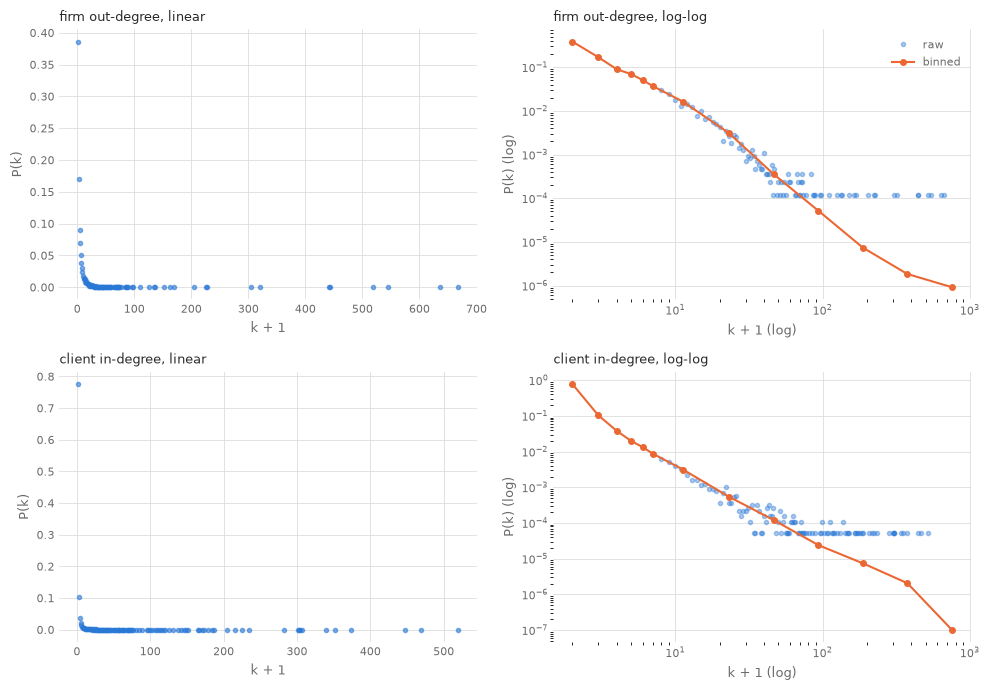

In [5]:
def raw_pk(degrees, N):
    '''Raw P(k), returned against u = k + 1 so it survives a log axis.'''
    u, counts = np.unique(np.asarray(degrees) + 1, return_counts=True)
    return u, counts / N


def bin_edges(umax):
    '''Width-1 bins for u = 1..7, doubling bins after that.'''
    e = list(range(1, 9))
    hi = 8
    while hi <= umax:
        e.append(hi * 2)
        hi *= 2
    return np.array(e)


def binned_pk(degrees, N):
    u = np.asarray(degrees) + 1
    e = bin_edges(u.max())
    counts, _ = np.histogram(u, bins=e)
    widths = np.diff(e)
    density = counts / (widths * N)
    centres = np.array([np.exp(np.mean(np.log(np.arange(lo, hi)))) for lo, hi in zip(e[:-1], e[1:])])
    keep = counts > 0
    return centres[keep], density[keep]


fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, (label, ks) in enumerate([("firm out-degree", k_firm), ("client in-degree", k_client)]):
    u, p = raw_pk(ks, len(ks))
    bu, bp = binned_pk(ks, len(ks))
    ax = axes[row, 0]
    ax.plot(u, p, "o", color=BLUE, markersize=3, alpha=0.6)
    style(ax, "k + 1", "P(k)")
    ax.set_title(f"{label}, linear", fontsize=9, loc="left", color=INK)

    ax = axes[row, 1]
    ax.plot(u, p, "o", color=BLUE, markersize=3, alpha=0.4, label="raw")
    ax.plot(bu, bp, "o-", color=ORANGE, markersize=4, label="binned")
    ax.set_xscale("log"); ax.set_yscale("log")
    style(ax, "k + 1 (log)", "P(k) (log)")
    ax.set_title(f"{label}, log-log", fontsize=9, loc="left", color=INK)
    if row == 0:
        ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
fig.tight_layout()
plt.show()

Where the bins are width 1 the binned curve should sit exactly on the raw points.

In [6]:
u, p = raw_pk(k_firm, len(k_firm))
bu, bp = binned_pk(k_firm, len(k_firm))
match = np.allclose(p[:6], bp[:6])
print("first six raw and binned points for firm out-degree coincide:", match)
assert match

first six raw and binned points for firm out-degree coincide: True


In [7]:
top_firm_nodes = sorted(firm_nodes, key=lambda n: -firm_deg[n])[:5]
print("top five firms by number of clients placed at (out-degree):")
for n in top_firm_nodes:
    print(f"  {resolver().label(n[1]):<30} out-degree {firm_deg[n]:>4}")

top_client_nodes = sorted(client_nodes, key=lambda n: -client_deg[n])[:5]
print("top five clients by number of vendors used (in-degree):")
for n in top_client_nodes:
    print(f"  {resolver().label(n[1]):<30} in-degree {client_deg[n]:>4}")

top five firms by number of clients placed at (out-degree):
  Cognizant                      out-degree  666
  Tata Consultancy Services      out-degree  635
  Compunnel Software             out-degree  543
  EY                             out-degree  517
  Accenture                      out-degree  443
top five clients by number of vendors used (in-degree):
  Verizon                        in-degree  518
  Wells Fargo                    in-degree  468
  Capital One                    in-degree  446
  JPMorgan Chase                 in-degree  372
  American Express               in-degree  351


**Strength.** A firm or client's strength is its total number of certified filings, summed over
its edges (`weight`). By construction strength &ge; degree for every node.

In [8]:
firm_strength = dict(g.degree(firm_nodes, weight="weight"))
client_strength = dict(g.degree(client_nodes, weight="weight"))

top_firm_strength = sorted(firm_nodes, key=lambda n: -firm_strength[n])[:5]
print("top five firms by strength (total filings placed):")
for n in top_firm_strength:
    print(f"  {resolver().label(n[1]):<30} strength {firm_strength[n]:>5}   degree {firm_deg[n]:>4}")

single_vendor_clients = int(np.sum(k_client == 1))
print(f"\nsingle-vendor clients: {single_vendor_clients:,}")
assert single_vendor_clients == 14679

top five firms by strength (total filings placed):
  Tata Consultancy Services      strength  7188   degree  635
  Cognizant                      strength  5044   degree  666
  Infosys                        strength  3766   degree  320
  HCL                            strength  2184   degree  441
  LTIMindtree                    strength  2123   degree  304

single-vendor clients: 14,679


**In/out-degree meaning, the 1.4 analogue.** A client's in-degree counts the vendors staffing it:
a high in-degree client shops around for H-1B labor. A firm's out-degree counts the clients it
reaches: a high out-degree firm is a broad-spectrum outsourcer. The two are structurally different
quantities (client count vs. firm count) so their distributions are not comparable point for point,
only shape for shape.

## 2.2: The random network, as code (same-size only)

A bipartite `gnmk_random_graph` with this network's firm count, client count and edge count, set
against the real network: giant size, isolates, max degree, average distance in the giant. The
random graph is not degree-preserving, so this is the "same size, nothing else" baseline, not the
degree-preserving one used from 2.8 onward.

In [9]:
t0 = time.time()
gnm = nx.bipartite.gnmk_random_graph(n_firms, n_clients, g.number_of_edges(), seed=SEED)
print(f"gnmk built in {time.time() - t0:.2f}s")

gnm_giant = giant_of(gnm)
gnm_isolates = sum(1 for _, d in gnm.degree() if d == 0)
real_isolates = sum(1 for _, d in g.degree() if d == 0)
gnm_maxdeg = max(d for _, d in gnm.degree())
real_maxdeg = max(k_firm.max(), k_client.max())

# Average distance in the giant: sample pairs (the giant has >20k nodes, exact APSP is too slow).
def sample_avg_distance(h, samples=2000, seed=SEED):
    nodes = list(h.nodes())
    rnd = random.Random(seed)
    dists = []
    for _ in range(samples):
        a, b = rnd.sample(nodes, 2)
        try:
            dists.append(nx.shortest_path_length(h, a, b))
        except nx.NetworkXNoPath:
            pass
    return np.mean(dists)

t0 = time.time()
gnm_avgd = sample_avg_distance(gnm_giant)
real_avgd = sample_avg_distance(giant)
print(f"avg distance sampled (2000 pairs each) in {time.time() - t0:.1f}s")

print(f"{'':<28}{'real':>12}{'gnmk (same size)':>20}")
print(f"{'nodes in giant':<28}{giant.number_of_nodes():>12,}{gnm_giant.number_of_nodes():>20,}")
print(f"{'isolates':<28}{real_isolates:>12}{gnm_isolates:>20}")
print(f"{'max degree':<28}{real_maxdeg:>12}{gnm_maxdeg:>20}")
print(f"{'avg distance (sampled)':<28}{real_avgd:>12.2f}{gnm_avgd:>20.2f}")

gnmk built in 0.16s


avg distance sampled (2000 pairs each) in 0.5s
                                    real    gnmk (same size)
nodes in giant                    21,759              25,507
isolates                               0                1838
max degree                           666                  15
avg distance (sampled)              5.76                8.24


The random graph has 1,838 isolates against 0 in the real network (printed above): at this average
degree, placing edges independently at random misses some nodes entirely, while the real network
has none by construction (a node exists here only because it has a filing). Wiring at random also
flattens the degree distribution: the random graph's maximum degree is 15 against the real
network's 666, since no mechanism concentrates edges onto a few nodes the way real staffing
contracts do. That flatter degree distribution, not the isolates, is why the random graph's average
distance is longer (8.24 against 5.76 hops, sampled): with no high-degree hubs to act as shortcuts,
a path between two random nodes has to cross more intermediate steps. Both are still short relative
to network size, so both count as "small worlds" in the loose logarithmic sense, but the real
network is the tighter one.

## 2.6: Is it a power law?

CCDFs of firm degree, client degree and firm strength, all needing no binning. A rough exponent
from the slope, then `powerlaw.Fit` comparing a power law against a log-normal on firm degree, and
the same CCDFs against the bipartite random graph from 2.2. The LLM-grading sub-item is skipped.

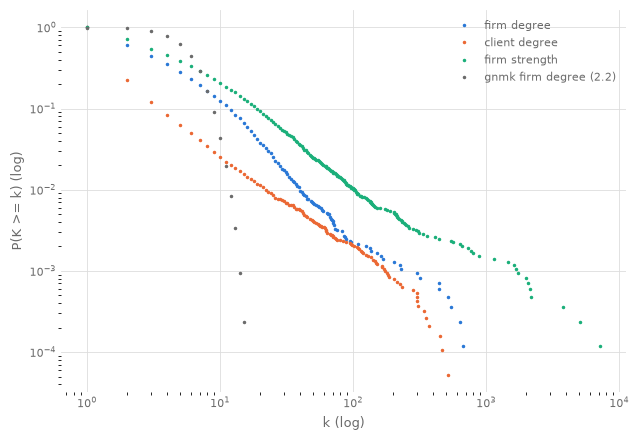

rough CCDF slope for firm degree: -1.49  ->  gamma approx 2.49
gnmk firm degree: max 15, vs real firm degree max 666


In [10]:
def ccdf(x):
    x = np.sort(np.asarray(x))
    n = len(x)
    uniq = np.unique(x)
    p = np.array([(x >= u).sum() / n for u in uniq])
    return uniq, p

gnm_firm_deg = np.array([d for n, d in gnm.degree() if gnm.nodes[n]["bipartite"] == 0])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, ks, c in [("firm degree", k_firm, BLUE), ("client degree", k_client, ORANGE),
                      ("firm strength", np.array(list(firm_strength.values())), GREEN),
                      ("gnmk firm degree (2.2)", gnm_firm_deg, MUTED)]:
    u, p = ccdf(ks)
    ax.plot(u, p, ".", color=c, markersize=3, label=label)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "k (log)", "P(K >= k) (log)")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
fig.tight_layout()
plt.show()

# a rough gamma from the CCDF's log-log slope in its central range (avoid the very ends)
u, p = ccdf(k_firm)
mid = slice(len(u) // 10, len(u) - len(u) // 20)
slope, _ = np.polyfit(np.log(u[mid]), np.log(p[mid]), 1)
gamma_rough = 1 - slope  # CCDF slope is -(gamma - 1)
print(f"rough CCDF slope for firm degree: {slope:.2f}  ->  gamma approx {gamma_rough:.2f}")
print(f"gnmk firm degree: max {gnm_firm_deg.max()}, vs real firm degree max {k_firm.max()}")

In [11]:
import warnings

# powerlaw's automatic xmin search picked xmin=14 on a first try, leaving too few points above it
# for a stable lognormal fit (it warned "No valid fits found for distribution lognormal" and the
# comparison came back meaningless). Fixing xmin=1 fits both distributions over the full range.
fit_auto = powerlaw.Fit(k_firm, discrete=True, verbose=False)
print(f"automatic xmin: {fit_auto.power_law.xmin}")

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    fit = powerlaw.Fit(k_firm, discrete=True, xmin=1, verbose=False)
    R, pval = fit.distribution_compare("power_law", "lognormal")
    lognormal_failed = any("No valid fits found" in str(w.message) for w in caught)

if lognormal_failed:
    print("lognormal fit still failed at xmin=1; the power law vs. lognormal comparison cannot be made.")
else:
    print(f"powerlaw.Fit on firm degree, xmin fixed at 1: alpha = {fit.power_law.alpha:.2f}")
    print(f"power law vs lognormal: R = {R:.2f} (negative favours lognormal), p = {pval:.2e}")

automatic xmin: 14.0
powerlaw.Fit on firm degree, xmin fixed at 1: alpha = 1.70
power law vs lognormal: R = -571.69 (negative favours lognormal), p = 7.47e-81


The gnmk random graph's degree distribution falls off far faster than the real one (see the max
degree printed above): its CCDF is a short, steep curve while the real firm-degree CCDF stretches
into much higher degrees, a heavy tail that a graph with no preferential structure does not produce.
Whether that tail is a power law is a separate question. With `xmin` fixed at 1 the comparison
above is valid (no fit failure), and `R` is strongly negative with a small `p`: on this test, a
log-normal fits firm degree better than a power law, over the full range of degrees. The same test on the tail alone, at the automatic `xmin` of 14, could not fit a log-normal at all, so it says nothing about the tail: whether the tail follows a power law stays open. That is the
caution 2.6 is built to teach: a heavy tail on a log-log plot is not a power-law claim without a
fit and a comparison against an alternative.

## 2.8: Compared to what, properly

The brief's three flawed baselines, reinterpreted for a bipartite network first (reciprocity has
no meaning here: every edge has one firm end and one client end, so "does A link back to B" is not
a question this graph can ask. The value is 0 by construction and stays 0 under every null too).
Then the analysis: bipartite clustering against `rewire()` and `gnmk` nulls, on the core (the full
graph is too slow for the null loop).

**Clustering, bipartite-style.** Ordinary clustering counts triangles, and this graph has none.
The substitute is the Robins-Alexander bipartite clustering coefficient
(`networkx.bipartite.robins_alexander_clustering`): it counts 4-cycles (a firm-client-firm-client
square) against the paths of length 3 that could have closed one, the bipartite analogue of "how
many of my neighbours' neighbours' neighbours end up back at a neighbour of mine." `nx.
square_clustering` is the per-node version of the same idea; we use the network-level
Robins-Alexander number so we have one scalar to shuffle-test.

`networkx`'s own implementation takes several seconds per call on the core, too slow for the
200 null draws below (100 `rewire()` plus 100 `gnmk`). We reimplement it as one sparse matrix
product and validate it against networkx to machine precision before trusting it.

In [12]:
def robins_alexander_fast(bg, firm_side="F"):
    '''Robins-Alexander bipartite clustering: 4 * (closed 4-cycles) / (paths of length 3).
    One sparse matrix product instead of networkx's per-node Python loop.'''
    firms = [n for n in bg if n[0] == firm_side]
    clients = [n for n in bg if n[0] != firm_side]
    fi = {f: i for i, f in enumerate(firms)}
    ci = {c: i for i, c in enumerate(clients)}
    r, c = zip(*[((fi[u], ci[v]) if u[0] == firm_side else (fi[v], ci[u])) for u, v in bg.edges()])
    B = sparse.csr_matrix((np.ones(len(r)), (r, c)), shape=(len(firms), len(clients)))
    co = (B @ B.T).toarray()
    np.fill_diagonal(co, 0)
    c4 = (co * (co - 1) / 2).sum() / 2  # each firm pair counted twice
    deg_f = np.asarray(B.sum(axis=1)).flatten()
    deg_c = np.asarray(B.sum(axis=0)).flatten()
    l3 = sum((deg_f[fi[u]] - 1) * (deg_c[ci[v]] - 1) if u[0] == firm_side else
             (deg_f[fi[v]] - 1) * (deg_c[ci[u]] - 1) for u, v in bg.edges())
    return 4 * c4 / l3 if l3 > 0 else 0.0


t0 = time.time()
ra_nx = nx.bipartite.robins_alexander_clustering(core)
t_nx = time.time() - t0
ra_fast = robins_alexander_fast(core)
print(f"networkx RA(core) = {ra_nx:.10f} in {t_nx:.1f}s   fast RA(core) = {ra_fast:.10f}")
assert abs(ra_nx - ra_fast) < 1e-9

networkx RA(core) = 0.0538080982 in 7.3s   fast RA(core) = 0.0538080982


In [13]:
real_ra = robins_alexander_fast(core)
print(f"real core: bipartite clustering (Robins-Alexander) = {real_ra:.4f}")
print(f"undirected transitivity: {nx.transitivity(core)}   triangles: {sum(nx.triangles(core).values())}")
assert nx.transitivity(core) == 0 and sum(nx.triangles(core).values()) == 0

n_firms_core = sum(1 for n in core if n[0] == "F")
n_clients_core = sum(1 for n in core if n[0] == "C")
m_core = core.number_of_edges()


def gnmk_labeled(nf, nc, m, seed):
    h = nx.bipartite.gnmk_random_graph(nf, nc, m, seed=seed)
    return nx.relabel_nodes(h, {n: (("F", n) if d["bipartite"] == 0 else ("C", n)) for n, d in h.nodes(data=True)})


rewire_ra, gnmk_ra, rewire_isolates, gnmk_isolates = [], [], [], []
for i in tracked("2.8: rewire + gnmk clustering nulls", DRAWS_CLUSTERING):
    h = rewire(core, rng)
    if i == 0:
        check_rewire(core, h)
    rewire_ra.append(robins_alexander_fast(h))
    rewire_isolates.append(sum(1 for _, d in h.degree() if d == 0))
    gnm_c = gnmk_labeled(n_firms_core, n_clients_core, m_core, SEED + i)
    gnmk_ra.append(robins_alexander_fast(gnm_c))
    gnmk_isolates.append(sum(1 for _, d in gnm_c.degree() if d == 0))
rewire_ra, gnmk_ra = np.array(rewire_ra), np.array(gnmk_ra)

for label, null in [("rewire()", rewire_ra), ("gnmk", gnmk_ra)]:
    z = (real_ra - null.mean()) / null.std()
    p = (np.sum(null >= real_ra) + 1) / (len(null) + 1)
    print(f"{label:<10} null mean {null.mean():.4f} sd {null.std():.4f}   real z = {z:.1f}   p = {p:.3f}")

print(f"isolates: real 0, rewire() draws mean {np.mean(rewire_isolates):.1f}, "
      f"gnmk draws mean {np.mean(gnmk_isolates):.1f}")

real core: bipartite clustering (Robins-Alexander) = 0.0538


undirected transitivity: 0   triangles: 0


2.8: rewire + gnmk clustering nulls: 10/100 (10%), 12s elapsed, about 1m49s left


2.8: rewire + gnmk clustering nulls: 20/100 (20%), 19s elapsed, about 1m16s left


2.8: rewire + gnmk clustering nulls: 30/100 (30%), 26s elapsed, about 1m1s left


...

2.8: rewire + gnmk clustering nulls: 70/100 (70%), 52s elapsed, about 22s left


2.8: rewire + gnmk clustering nulls: 80/100 (80%), 58s elapsed, about 14s left


2.8: rewire + gnmk clustering nulls: 90/100 (90%), 1m7s elapsed, about 7s left


2.8: rewire + gnmk clustering nulls: 100/100 (100%), 1m13s elapsed, about 0s left


rewire()   null mean 0.0379 sd 0.0007   real z = 21.9   p = 0.010
gnmk       null mean 0.0028 sd 0.0001   real z = 442.9   p = 0.010
isolates: real 0, rewire() draws mean 0.0, gnmk draws mean 1211.2


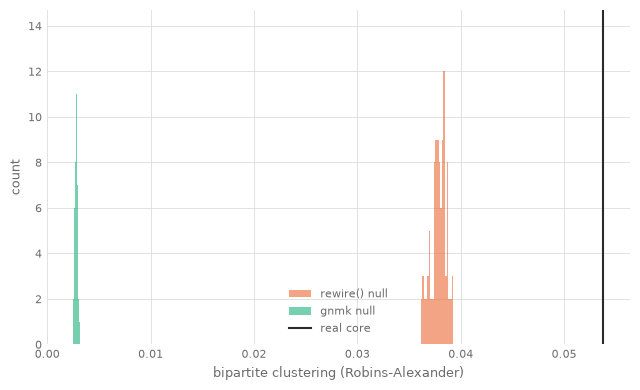

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(rewire_ra, bins=20, color=ORANGE, alpha=0.6, label="rewire() null")
ax.hist(gnmk_ra, bins=20, color=GREEN, alpha=0.6, label="gnmk null")
ax.axvline(real_ra, color=INK, linewidth=1.5, label="real core")
style(ax, "bipartite clustering (Robins-Alexander)", "count")
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED)
fig.tight_layout()
plt.show()

Since `rewire()` never drops a link (it swaps stub pairs in place, unlike `nx.configuration_model`
which can leave self-loops and parallel edges behind), the brief's "config model loses links"
contrast has no bipartite equivalent here: both nulls keep the full edge count, so any gap between
them is about wiring randomness alone, not about lost data. Isolated nodes: 0 in the real core, 0
in every `rewire()` draw (printed above: degree is preserved exactly), and about 1,211 on
average per `gnmk` draw (11% of the core), since placing edges independently at random misses a
sizeable share of nodes entirely at this density.

The real core's clustering sits far from both nulls (see the z-scores above): clients that share
one firm tend to share others too, a real concentration of the outsourcing market that neither
null, which only fixes degrees or only fixes the edge count, can produce on its own.

## 2.9: The friendship paradox, bipartite form

The paradox compares a neighbour's degree with the mean degree of the neighbour's own side, not
with the degree of the node that picked it (those are different quantities: a firm's client count
and a client's vendor count live on different scales, 1.6 gives their means as 5.32 and 2.38). Two
one-sided versions, both on the full graph (not the core, so the comparison lines up exactly with
1.6's population means):

(a) pick a random client, then one of its vendors at random: is that vendor's client count above
the mean firm client count?

(b) pick a random firm, then one of its clients at random: is that client's vendor count above the
mean client vendor count?

The bipartite formula for each: the mean degree seen this way is close to
&#9001;k&sup2;&#9002;/&#9001;k&#9002; of the side being landed on (Newman's friendship-paradox
identity; exact for a uniformly random edge, approximate here since picking a client then a random
vendor is not quite the same as picking a uniformly random edge).

In [15]:
def neighbor_degree_sample(bg, from_nodes, deg_dict, samples, rnd):
    '''Pick a node from from_nodes, then a random neighbour; return the neighbour's degree.'''
    out = []
    for _ in range(samples):
        a = rnd.choice(from_nodes)
        b = rnd.choice(list(bg.neighbors(a)))
        out.append(deg_dict[b])
    return np.array(out)


def paradox_formula(degrees):
    degrees = np.asarray(degrees, dtype=float)
    return (degrees ** 2).mean() / degrees.mean()


mean_firm_deg = k_firm.mean()
mean_client_deg = k_client.mean()
formula_firm = paradox_formula(k_firm)
formula_client = paradox_formula(k_client)
print(f"mean firm degree (1.6): {mean_firm_deg:.2f}   formula <k^2>/<k> over firms: {formula_firm:.2f}")
print(f"mean client degree (1.6): {mean_client_deg:.2f}   formula <k^2>/<k> over clients: {formula_client:.2f}")

mean firm degree (1.6): 5.32   formula <k^2>/<k> over firms: 64.58
mean client degree (1.6): 2.38   formula <k^2>/<k> over clients: 57.53


In [16]:
rnd = random.Random(SEED)
neighbor_firm = neighbor_degree_sample(g, client_nodes, firm_deg, FRIENDSHIP_SAMPLES, rnd)
rnd_same = random.Random(SEED)
random_firm = np.array([firm_deg[rnd_same.choice(firm_nodes)] for _ in range(FRIENDSHIP_SAMPLES)])
print("(a) client -> random vendor: vendor's client count")
print(f"  mean neighbour (firm) degree     {neighbor_firm.mean():.2f}")
print(f"  share >= mean firm degree        {np.mean(neighbor_firm >= mean_firm_deg):.3f}")
print(f"  share >= a random same-side firm {np.mean(neighbor_firm >= random_firm):.3f}")

rnd = random.Random(SEED + 1)
neighbor_client = neighbor_degree_sample(g, firm_nodes, client_deg, FRIENDSHIP_SAMPLES, rnd)
rnd_same = random.Random(SEED + 1)
random_client = np.array([client_deg[rnd_same.choice(client_nodes)] for _ in range(FRIENDSHIP_SAMPLES)])
print("\n(b) firm -> random client: client's vendor count")
print(f"  mean neighbour (client) degree     {neighbor_client.mean():.2f}")
print(f"  share >= mean client degree        {np.mean(neighbor_client >= mean_client_deg):.3f}")
print(f"  share >= a random same-side client {np.mean(neighbor_client >= random_client):.3f}")

(a) client -> random vendor: vendor's client count
  mean neighbour (firm) degree     84.75
  share >= mean firm degree        0.737
  share >= a random same-side firm 0.854

(b) firm -> random client: client's vendor count
  mean neighbour (client) degree     60.02
  share >= mean client degree        0.580
  share >= a random same-side client 0.905


In [17]:
# Nulls: rewire() (keeps every degree exactly) and the bipartite random graph, same full-graph size.
h = rewire(g, rng)
check_rewire(g, h)
firm_deg_h = dict(h.degree([n for n in h if n[0] == "F"]))
client_deg_h = dict(h.degree([n for n in h if n[0] == "C"]))
rnd = random.Random(SEED)
neighbor_firm_h = neighbor_degree_sample(h, [n for n in h if n[0] == "C"], firm_deg_h, FRIENDSHIP_SAMPLES, rnd)
rnd = random.Random(SEED + 1)
neighbor_client_h = neighbor_degree_sample(h, [n for n in h if n[0] == "F"], client_deg_h, FRIENDSHIP_SAMPLES, rnd)
print(f"rewire() null: (a) mean neighbour firm degree {neighbor_firm_h.mean():.2f}   "
      f"(b) mean neighbour client degree {neighbor_client_h.mean():.2f}")

gnm_full = gnmk_labeled(n_firms, n_clients, g.number_of_edges(), SEED)
firm_deg_gnm = dict(gnm_full.degree([n for n in gnm_full if n[0] == "F"]))
client_deg_gnm = dict(gnm_full.degree([n for n in gnm_full if n[0] == "C"]))
client_nodes_gnm_pos = [n for n in gnm_full if n[0] == "C" and gnm_full.degree(n) > 0]
firm_nodes_gnm_pos = [n for n in gnm_full if n[0] == "F" and gnm_full.degree(n) > 0]
rnd = random.Random(SEED)
neighbor_firm_gnm = neighbor_degree_sample(gnm_full, client_nodes_gnm_pos, firm_deg_gnm, FRIENDSHIP_SAMPLES, rnd)
rnd = random.Random(SEED + 1)
neighbor_client_gnm = neighbor_degree_sample(gnm_full, firm_nodes_gnm_pos, client_deg_gnm, FRIENDSHIP_SAMPLES, rnd)
print(f"gnmk null:     (a) mean neighbour firm degree {neighbor_firm_gnm.mean():.2f}   "
      f"(b) mean neighbour client degree {neighbor_client_gnm.mean():.2f}")

rewire() null: (a) mean neighbour firm degree 79.68   (b) mean neighbour client degree 65.59


gnmk null:     (a) mean neighbour firm degree 6.25   (b) mean neighbour client degree 3.33


Both directions show the paradox. A client's random vendor has on average many more clients (a)
than the mean firm (printed above), and most of the time more than a random firm too. A firm's
random client has on average many more vendors (b) than the mean client, and in the large majority
of samples more than a random client too. The gap between the sampled mean and the
&#9001;k&sup2;&#9002;/&#9001;k&#9002; formula is expected: the formula is exact only for a uniformly
random edge, and picking a client (or firm) uniformly first, then one of its neighbours, over- or
under-weights nodes slightly differently.

`rewire()` keeps the paradox at close to its real size on both sides, since it only reshuffles who
links to whom and leaves every degree untouched. `gnmk` collapses both numbers close to the plain
mean degree of each side, because its degrees are close to Poisson (low variance), so
&#9001;k&sup2;&#9002; is close to &#9001;k&#9002;&sup2;. The paradox depends on the variance of the
degree sequence, not on the specific wiring.

## 3.3: Distances, as code

Diameter, radius, center and the distance distribution on the core (igraph, not networkx: an
all-pairs computation over 10,528 nodes in pure Python would run for a long time). Distances
between two firms or two clients are even (you cross firm-client-firm-client...); a firm-to-client
distance is odd, since every step alternates sides.

Directed reachability: firm &rarr; client has no way back, so every strongly connected component is
a single node (no cycle can exist in a graph with edges going only one way between two disjoint
sets). We show that directly, then report directed reachability instead of an SCC-based measure.

In [18]:
nodes_core, ig_core, weights_core = to_igraph(core)
index_core = {n: i for i, n in enumerate(nodes_core)}

t0 = time.time()
diam = ig_core.diameter()
radius = min(ig_core.eccentricity())
ecc = ig_core.eccentricity()
center_idx = [i for i, e in enumerate(ecc) if e == radius]
print(f"core: diameter {diam}, radius {radius}, center size {len(center_idx)}   ({time.time()-t0:.1f}s)")
print("a few center members:", [resolver().label(nodes_core[i][1]) for i in center_idx[:5]])

# average distance, sampled (exact APSP over 10.5k nodes is affordable in igraph but path_length_hist gives it directly)
plh = ig_core.path_length_hist(directed=False)
total_pairs = sum(b[2] for b in plh.bins())
weighted_sum = sum(b[0] * b[2] for b in plh.bins())
avg_d = weighted_sum / total_pairs
print(f"average distance (all pairs, giant of core): {avg_d:.2f}")

core: diameter 20, radius 10.0, center size 198   (4.2s)
a few center members: ['3M', 'AT&T', 'Ally Financial', 'Amazon', 'American Express']
average distance (all pairs, giant of core): 5.33


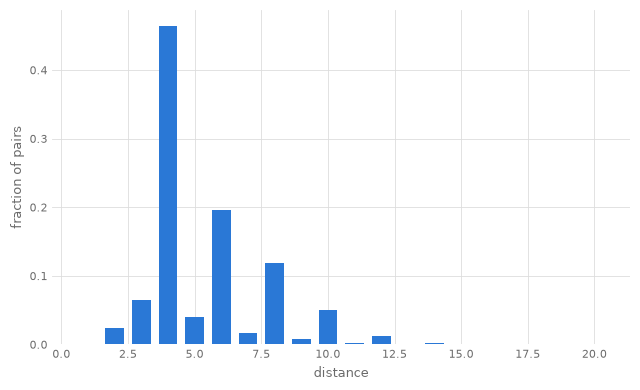

share of pairs at an even distance: 0.869 (firm-firm and client-client pairs)


In [19]:
dist_counts = Counter()
for b in plh.bins():
    dist_counts[int(b[0])] += b[2]
total = sum(dist_counts.values())
fig, ax = plt.subplots(figsize=(6.5, 4))
ds = sorted(dist_counts)
ax.bar(ds, [dist_counts[d] / total for d in ds], color=BLUE, width=0.7)
style(ax, "distance", "fraction of pairs")
fig.tight_layout()
plt.show()

even_share = sum(v for d, v in dist_counts.items() if d % 2 == 0) / total
print(f"share of pairs at an even distance: {even_share:.3f} (firm-firm and client-client pairs)")

In [20]:
# rewire() and gnmk nulls for the distance distribution, on the core.
h = rewire(core, rng)
gnm_c = gnmk_labeled(n_firms_core, n_clients_core, m_core, SEED)

def avg_distance_igraph(nxgraph):
    hg = giant_of(nxgraph)
    _, ig_h, _ = to_igraph(hg)
    plh_h = ig_h.path_length_hist(directed=False)
    tp = sum(b[2] for b in plh_h.bins())
    ws = sum(b[0] * b[2] for b in plh_h.bins())
    return ws / tp, hg.number_of_nodes()

d_rewire, n_rewire = avg_distance_igraph(h)
d_gnm, n_gnm = avg_distance_igraph(gnm_c)
print(f"real core avg distance:      {avg_d:.2f}  (n={core.number_of_nodes()})")
print(f"rewire() giant avg distance: {d_rewire:.2f}  (n={n_rewire})")
print(f"gnmk giant avg distance:     {d_gnm:.2f}  (n={n_gnm})")

real core avg distance:      5.33  (n=10528)
rewire() giant avg distance: 4.14  (n=10510)
gnmk giant avg distance:     5.23  (n=9305)


Both nulls reproduce a short average distance, since a small-world regime is generic at this
density, but neither matches the real value closely. `rewire()` runs shorter (4.14 against the
real 5.33): scrambling every hub's links at random scatters shortcuts across the whole core the
way a handful of random rewires shrink a Watts-Strogatz lattice, even though every node keeps its
real degree. `gnmk` lands closer to the real number (5.23) but over a visibly smaller giant
component (9,305 against the real 10,528 and rewire()'s 10,510), so its similar average distance
comes from a more fragmented network, not a more realistic one. Neither null reproduces the
*shape* of the real distance distribution's even/odd split on its own except by the same bipartite
construction, which every null here inherits automatically (any bipartite graph has this parity
property, real or randomized).

In [21]:
# Directed view: firm -> client only.
D = nx.DiGraph()
for (e, c), w in rows.groupby(["employer", "client"]).size().items():
    D.add_edge(("F", e), ("C", c), weight=int(w))

n_scc = nx.number_strongly_connected_components(D)
print(f"directed nodes {D.number_of_nodes():,}, strongly connected components {n_scc:,}")
assert n_scc == D.number_of_nodes()

n = D.number_of_nodes()
possible_pairs = n * (n - 1)
reachable_pairs = D.number_of_edges()  # every edge is the only path from its source to its target
reachable_share = reachable_pairs / possible_pairs
print(f"reachable ordered pairs: {reachable_pairs:,} of {possible_pairs:,} possible ({reachable_share:.5f})")
print("mean directed distance over reachable pairs: 1 (every firm-client edge is a direct hop, "
      "and no two-hop directed path exists: a client has no out-edges)")

directed nodes 27,397, strongly connected components 27,397
reachable ordered pairs: 45,113 of 750,568,212 possible (0.00006)
mean directed distance over reachable pairs: 1 (every firm-client edge is a direct hop, and no two-hop directed path exists: a client has no out-edges)


The brief's "find a pair with d(A,B) = 1 and d(B,A) >= 5" question has no answer in this network:
d(B,A) is infinite for every firm-client pair, since a client has no out-edges at all and cannot
reach anything. The directed view collapses to a single fact worth reporting instead (printed
above): reachability is exactly the edge list, one hop each, a small share of all possible ordered
pairs.

In [22]:
def bfs_hand(adj, source):
    '''Unweighted BFS: shortest-path distance from source to every reachable node.'''
    dist = {source: 0}
    frontier = [source]
    while frontier:
        nxt = []
        for u in frontier:
            for v in adj[u]:
                if v not in dist:
                    dist[v] = dist[u] + 1
                    nxt.append(v)
        frontier = nxt
    return dist


adj = {n: list(core.neighbors(n)) for n in core}
rnd = random.Random(SEED)
starts = rnd.sample(list(core.nodes()), 20)
ok = True
for s in starts:
    hand = bfs_hand(adj, s)
    nx_dist = nx.single_source_shortest_path_length(core, s)
    if hand != nx_dist:
        ok = False
        print("mismatch at", s)
print(f"hand-written BFS matches networkx on {len(starts)} random start nodes: {ok}")
assert ok

hand-written BFS matches networkx on 20 random start nodes: True


## 3.5: Centralities on the core

Degree, closeness, harmonic and betweenness, all on the undirected core (igraph for
betweenness/closeness, which would be slow in networkx at this size).

In [23]:
t0 = time.time()
deg_c = dict(zip(nodes_core, ig_core.degree()))
close_c = dict(zip(nodes_core, ig_core.closeness()))
harm_c = dict(zip(nodes_core, ig_core.harmonic_centrality()))
betw_c = dict(zip(nodes_core, ig_core.betweenness()))
print(f"centralities computed in {time.time() - t0:.1f}s")

tops = {}
for label, d in [("degree", deg_c), ("closeness", close_c), ("harmonic", harm_c), ("betweenness", betw_c)]:
    top10 = sorted(d, key=lambda n: -d[n])[:10]
    tops[label] = set(top10)
    print(f"\ntop ten by {label}:")
    for n in top10:
        print(f"  {n[0]}  {resolver().label(n[1]):<28} {label}={d[n]:.4g}")

overlap = set.intersection(*tops.values())
print(f"\ncharacters in all four top tens: {len(overlap)}")
for pair in [("degree", "closeness"), ("degree", "betweenness"), ("closeness", "harmonic"),
             ("betweenness", "harmonic")]:
    print(f"  overlap {pair[0]} & {pair[1]}: {len(tops[pair[0]] & tops[pair[1]])}")

centralities computed in 6.1s

top ten by degree:
  F  Cognizant                    degree=666
  F  Tata Consultancy Services    degree=635
  F  Compunnel Software           degree=543
  F  EY                           degree=517
  F  Accenture                    degree=443
  F  HCL                          degree=441
  F  Infosys                      degree=320
  F  LTIMindtree                  degree=304
  F  Capgemini                    degree=227
  F  Wipro                        degree=224

top ten by closeness:
  F  Compunnel Software           closeness=0.2952
  C  Verizon                      closeness=0.2921
  F  Tata Consultancy Services    closeness=0.2913
  F  Cognizant                    closeness=0.2896
  C  American Express             closeness=0.2864
  F  Accenture                    closeness=0.286
  C  AT&T                         closeness=0.2857
  F  EY                           closeness=0.2857
  F  HCL                          closeness=0.285
  C  Wells Fargo    

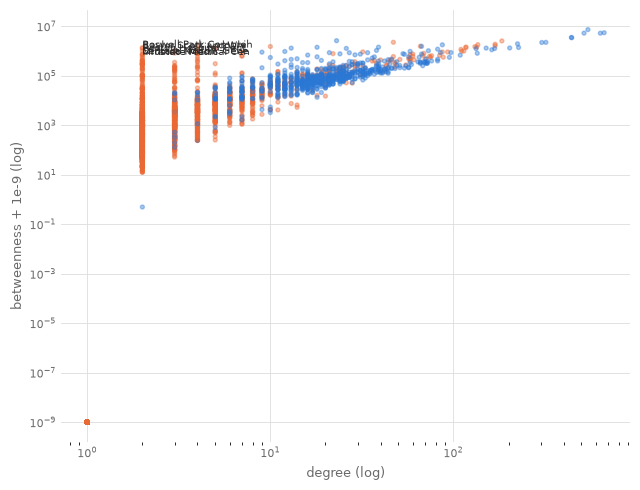

labelled outliers (highest betweenness relative to degree):
  C  Roswell Park Comprehensive Cancer Center degree    2  betweenness 1383663.4  vendors: State University of NEW York at Buffalo + Populus (share 0 other clients besides this one)
  C  Baylor Scott and White       degree    2  betweenness 1285284.9  vendors: Nuvasive Clinical Services Monitoring + JKV International (share 0 other clients besides this one)
  C  Reston Hospital Center       degree    2  betweenness 1039714.2  vendors: Usacs Medical + Nuvasive Clinical Services Monitoring (share 0 other clients besides this one)
  C  Sentara Norfolk General Hospital degree    2  betweenness 773792.7  vendors: EY + Siemens Medical Solutions (share 0 other clients besides this one)
  C  Orlando Health               degree    2  betweenness 718060.2  vendors: Source Infotech + Adventist Health System Sunbelt (share 0 other clients besides this one)
  C  Midstate Medical Center      degree    2  betweenness 700820.0  vendors: Hartf

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 5))
xs = np.array([deg_c[n] for n in nodes_core])
ys = np.array([betw_c[n] + 1e-9 for n in nodes_core])
colors = [BLUE if n[0] == "F" else ORANGE for n in nodes_core]
ax.scatter(xs, ys, c=colors, s=8, alpha=0.4)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "degree (log)", "betweenness + 1e-9 (log)")

# label the outliers: highest betweenness for their degree bracket
resid = np.log(ys) - np.polyfit(np.log(xs + 1), np.log(ys), 1)[0] * np.log(xs + 1)
outlier_idx = np.argsort(-resid)[:6]
for i in outlier_idx:
    n = nodes_core[i]
    ax.annotate(resolver().label(n[1])[:20], (xs[i], ys[i]), fontsize=7, color=INK)
fig.tight_layout()
plt.show()

print("labelled outliers (highest betweenness relative to degree):")
for i in outlier_idx:
    n = nodes_core[i]
    if n[0] == "C":
        v1, v2 = list(core.neighbors(n))
        shared = len((set(core.neighbors(v1)) & set(core.neighbors(v2))) - {n})
        extra = (f"  vendors: {resolver().label(v1[1])} + {resolver().label(v2[1])}"
                 f" (share {shared} other client{'s' if shared != 1 else ''} besides this one)")
    else:
        extra = ""
    print(f"  {n[0]}  {resolver().label(n[1]):<28} degree {deg_c[n]:>4}  betweenness {betw_c[n]:.1f}{extra}")

All six labelled outliers are degree-2 clients (hospitals and health systems), each linked to
exactly two firms (printed above). A degree-2 client's betweenness is high when its two vendors
otherwise reach separate parts of the core: for every one of the six, its two vendors share no
other client besides the outlier itself (printed above), so the outlier is the only path between
those two vendors' neighbourhoods. The mechanism is the same shape as Rockman's two-link bridge in
the Marvel case: a low-degree node's betweenness depends on which two neighbours it connects,
not on how many it has.

## 3.7: PageRank: firm &rarr; client makes every client dangling

On the directed graph firm &rarr; client, a client has no out-edges: every client is a dangling
node. Standard PageRank redistributes a dangling node's mass uniformly over the whole graph at
every step, so nearly all of PageRank's teleportation mass on this network comes from clients, not
from the damping factor alone. We also run it client &rarr; firm (which firms do clients "point to"
by using them), and weighted by filings.

In [25]:
dangling = [n for n in D if D.out_degree(n) == 0]
print(f"dangling nodes (clients): {len(dangling):,} of {D.number_of_nodes():,} "
      f"({len(dangling) / D.number_of_nodes():.1%})")

dangling nodes (clients): 18,924 of 27,397 (69.1%)


In [26]:
def pagerank_hand(graph_d, alpha=0.85, weight=None, tol=1e-12, max_iter=1000):
    '''Power iteration with dangling-node handling: a node with no out-edges hands its mass
    to every node uniformly, exactly as networkx does by default.'''
    nodes = list(graph_d.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)
    out_w = {}
    for u in nodes:
        edges = graph_d.out_edges(u, data=True)
        if weight is None:
            out_w[u] = [(idx[v], 1.0) for _, v, _ in edges]
            total = len(out_w[u])
        else:
            out_w[u] = [(idx[v], d.get(weight, 1.0)) for _, v, d in edges]
            total = sum(w for _, w in out_w[u])
        out_w[u] = [(j, w / total) for j, w in out_w[u]] if total > 0 else []
    dangling_idx = [idx[u] for u in nodes if not out_w[u]]

    pr = np.full(n, 1.0 / n)
    for _ in range(max_iter):
        new = np.zeros(n)
        dangling_mass = pr[dangling_idx].sum()
        for u in nodes:
            i = idx[u]
            for j, w in out_w[u]:
                new[j] += alpha * pr[i] * w
        new += alpha * dangling_mass / n
        new += (1 - alpha) / n
        if np.abs(new - pr).sum() < tol:
            pr = new
            break
        pr = new
    return dict(zip(nodes, pr))


t0 = time.time()
pr_hand = pagerank_hand(D, alpha=0.85)
print(f"hand PageRank in {time.time() - t0:.1f}s")

hand PageRank in 0.4s


In [27]:
for alpha in (0.5, 0.85, 0.95):
    hand = pagerank_hand(D, alpha=alpha, tol=1e-12, max_iter=500)
    lib = nx.pagerank(D, alpha=alpha, weight=None, tol=1e-12, max_iter=500)
    diff = max(abs(hand[n] - lib[n]) for n in D)
    print(f"alpha={alpha}: max abs diff hand vs nx.pagerank = {diff:.2e}")
    assert diff < 1e-9

alpha=0.5: max abs diff hand vs nx.pagerank = 1.41e-11


alpha=0.85: max abs diff hand vs nx.pagerank = 2.11e-11


alpha=0.95: max abs diff hand vs nx.pagerank = 3.21e-11


In [28]:
pr_client_top = sorted([n for n in D if n[0] == "C"], key=lambda n: -pr_hand[n])[:10]
indeg_top = sorted([n for n in D if n[0] == "C"], key=lambda n: -D.in_degree(n))[:10]
print("top ten clients by PageRank:")
for n in pr_client_top:
    print(f"  {resolver().label(n[1]):<28} PR={pr_hand[n]:.2e}  in-degree {D.in_degree(n)}")
print(f"\noverlap PageRank top ten & in-degree top ten: {len(set(pr_client_top) & set(indeg_top))}")

top ten clients by PageRank:
  Verizon                      PR=2.84e-03  in-degree 518
  Wells Fargo                  PR=2.20e-03  in-degree 468
  Capital One                  PR=2.01e-03  in-degree 446
  T-Mobile                     PR=1.89e-03  in-degree 339
  American Express             PR=1.69e-03  in-degree 351
  JPMorgan Chase               PR=1.65e-03  in-degree 372
  Freddie Mac                  PR=1.62e-03  in-degree 306
  Apple                        PR=1.61e-03  in-degree 300
  AT&T                         PR=1.48e-03  in-degree 303
  Walmart                      PR=1.42e-03  in-degree 302

overlap PageRank top ten & in-degree top ten: 10


In [29]:
# client -> firm, and weighted by filings.
Drev = D.reverse(copy=True)
pr_rev = pagerank_hand(Drev, alpha=0.85)
pr_firm_top = sorted([n for n in Drev if n[0] == "F"], key=lambda n: -pr_rev[n])[:10]
print("top ten firms by PageRank on client -> firm (\"which firms do clients point to\"):")
for n in pr_firm_top:
    print(f"  {resolver().label(n[1]):<28} PR={pr_rev[n]:.2e}")

pr_weighted = pagerank_hand(D, alpha=0.85, weight="weight")
lib_weighted = nx.pagerank(D, alpha=0.85, weight="weight", tol=1e-12, max_iter=500)
diff_w = max(abs(pr_weighted[n] - lib_weighted[n]) for n in D)
print(f"\nweighted PageRank hand vs nx max abs diff: {diff_w:.2e}")
assert diff_w < 1e-9
pr_weighted_top = sorted([n for n in D if n[0] == "C"], key=lambda n: -pr_weighted[n])[:10]
print("top ten clients by weighted PageRank:")
for n in pr_weighted_top:
    print(f"  {resolver().label(n[1]):<28} PR={pr_weighted[n]:.2e}")

top ten firms by PageRank on client -> firm ("which firms do clients point to"):
  Cognizant                    PR=7.46e-03
  EY                           PR=5.63e-03
  Tata Consultancy Services    PR=5.62e-03
  HCL                          PR=4.41e-03
  Compunnel Software           PR=4.11e-03
  Accenture                    PR=3.82e-03
  LTIMindtree                  PR=3.18e-03
  Grandison Management         PR=2.45e-03
  Infosys                      PR=2.34e-03
  Wipro                        PR=2.12e-03



weighted PageRank hand vs nx max abs diff: 2.19e-11
top ten clients by weighted PageRank:
  Verizon                      PR=2.95e-03
  Wells Fargo                  PR=2.41e-03
  Capital One                  PR=2.32e-03
  T-Mobile                     PR=1.93e-03
  American Express             PR=1.91e-03
  Apple                        PR=1.77e-03
  JPMorgan Chase               PR=1.73e-03
  Freddie Mac                  PR=1.60e-03
  Walmart                      PR=1.59e-03
  AT&T                         PR=1.53e-03


**The dangling-node question is the finding to report here.** Every client dead-ends the walk, so
at every step the mass sitting on clients (69.1% of the network's nodes) gets handed back out
uniformly instead of following a business relationship. PageRank on firm-&rarr;client is dominated
by this redistribution rule, not by the graph's structure, and its top-ten client list mostly
tracks in-degree (a client used by many vendors) rather than revealing anything the raw count did
not. The client-&rarr;firm direction is more informative: no node is dangling there (every client
has at least one vendor), so a firm's rank reflects how many clients treat it as their vendor,
weighted by how exclusive each client's relationship to that firm
is.

## 3.8: Brokers, compared to what

`rewire()` draws of the core, z-scored betweenness and harmonic centrality (harmonic rather than
closeness: closeness on a disconnected draw is only defined within each component, and comparing
raw closeness values across a component boundary is meaningless, while harmonic centrality treats
an unreachable node as a zero contribution and is well defined everywhere).

We time one draw's betweenness first to size `DRAWS_BETWEENNESS`.

In [30]:
h = rewire(core, rng)
_, ig_h, _ = to_igraph(h)
t0 = time.time()
ig_h.betweenness()
per_draw = time.time() - t0
DRAWS_BETWEENNESS = 50
print(f"one igraph betweenness on a rewired core: {per_draw:.2f}s   "
      f"-> {DRAWS_BETWEENNESS} draws (betweenness+harmonic) about "
      f"{DRAWS_BETWEENNESS * per_draw * 1.5 / 60:.1f} min")

one igraph betweenness on a rewired core: 3.11s   -> 50 draws (betweenness+harmonic) about 3.9 min


In [31]:
degree1 = {n for n in core if deg_c[n] == 1}
print(f"degree-1 nodes (excluded from the z-score, betweenness is 0 in every draw by construction): "
      f"{len(degree1):,} of {core.number_of_nodes():,}")

betw_null = {n: [] for n in nodes_core}
harm_null = {n: [] for n in nodes_core}
disconnected_draws = 0
for i in tracked("3.8: rewire betweenness/harmonic nulls", DRAWS_BETWEENNESS):
    hd = rewire(core, rng)
    if nx.number_connected_components(hd) > 1:
        disconnected_draws += 1
    hnodes, ig_hd, _ = to_igraph(hd)
    b = dict(zip(hnodes, ig_hd.betweenness()))
    hc = dict(zip(hnodes, ig_hd.harmonic_centrality()))
    for n in nodes_core:
        betw_null[n].append(b.get(n, 0.0))
        harm_null[n].append(hc.get(n, 0.0))

print(f"disconnected draws: {disconnected_draws} of {DRAWS_BETWEENNESS} "
      "(computed on the draw as-is when disconnected, per the brief)")

degree-1 nodes (excluded from the z-score, betweenness is 0 in every draw by construction): 7,549 of 10,528


3.8: rewire betweenness/harmonic nulls: 5/50 (10%), 27s elapsed, about 4m10s left


3.8: rewire betweenness/harmonic nulls: 10/50 (20%), 51s elapsed, about 3m26s left


3.8: rewire betweenness/harmonic nulls: 15/50 (30%), 1m11s elapsed, about 2m46s left


3.8: rewire betweenness/harmonic nulls: 20/50 (40%), 1m31s elapsed, about 2m17s left


...

3.8: rewire betweenness/harmonic nulls: 35/50 (70%), 2m31s elapsed, about 1m4s left


3.8: rewire betweenness/harmonic nulls: 40/50 (80%), 2m50s elapsed, about 42s left


3.8: rewire betweenness/harmonic nulls: 45/50 (90%), 3m9s elapsed, about 21s left


3.8: rewire betweenness/harmonic nulls: 50/50 (100%), 3m29s elapsed, about 0s left


disconnected draws: 49 of 50 (computed on the draw as-is when disconnected, per the brief)


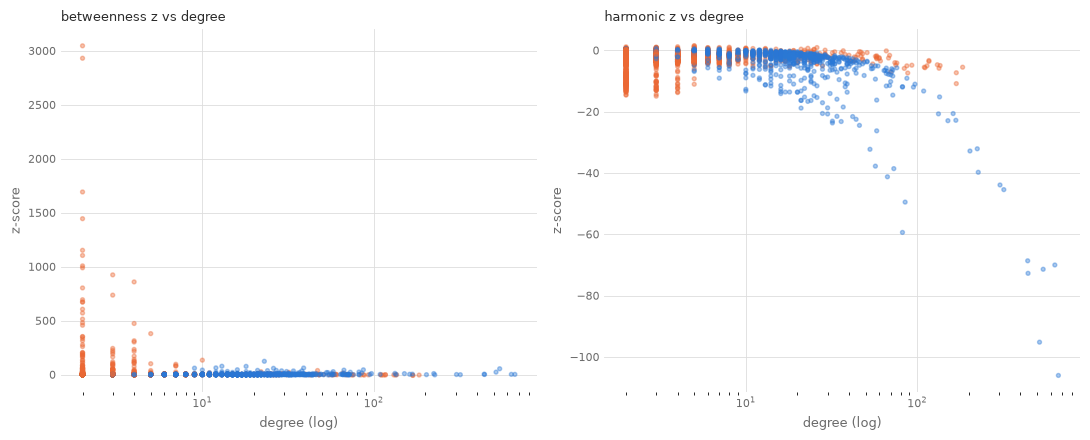

highest betweenness z-score (biggest positive surprise):
  C  Roswell Park Comprehensive Cancer Center degree    2  z=3045.4
  C  Baylor Scott and White       degree    2  z=2930.2
  C  Sentara Norfolk General Hospital degree    2  z=1691.4
  C  Orlando Health               degree    2  z=1443.7
  C  Reston Hospital Center       degree    2  z=1151.0
  C  Midstate Medical Center      degree    2  z=1103.1

lowest betweenness z-score (least broker-like for their degree):
  C  Capital One                  degree  169  z=-8.6
  C  Wells Fargo                  degree  169  z=-6.8
  C  Walmart                      degree  114  z=-5.8
  C  Vanguard                     degree   88  z=-5.8
  C  Verizon                      degree  184  z=-5.1
  C  Fannie Mae                   degree   84  z=-4.8

mean |z|: betweenness 12.74   harmonic 2.99
top five by |harmonic z|:
  F  Cognizant                    degree  666  z=-106.1
  F  EY                           degree  517  z=-95.2
  F  Accenture     

In [32]:
z_betw, z_harm = {}, {}
for n in nodes_core:
    if n in degree1:
        continue
    null_b = np.array(betw_null[n])
    if null_b.std() > 0:
        z_betw[n] = (betw_c[n] - null_b.mean()) / null_b.std()
    null_h = np.array(harm_null[n])
    if null_h.std() > 0:
        z_harm[n] = (harm_c[n] - null_h.mean()) / null_h.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, zdict, title in [(axes[0], z_betw, "betweenness z vs degree"), (axes[1], z_harm, "harmonic z vs degree")]:
    xs = [deg_c[n] for n in zdict]
    ys = [zdict[n] for n in zdict]
    colors = [BLUE if n[0] == "F" else ORANGE for n in zdict]
    ax.scatter(xs, ys, c=colors, s=8, alpha=0.4)
    ax.set_xscale("log")
    style(ax, "degree (log)", "z-score")
    ax.set_title(title, fontsize=9, loc="left", color=INK)
fig.tight_layout()
plt.show()

top_z_betw = sorted(z_betw, key=lambda n: -z_betw[n])[:6]
print("highest betweenness z-score (biggest positive surprise):")
for n in top_z_betw:
    print(f"  {n[0]}  {resolver().label(n[1]):<28} degree {deg_c[n]:>4}  z={z_betw[n]:.1f}")

low_z_betw = sorted(z_betw, key=lambda n: z_betw[n])[:6]
print("\nlowest betweenness z-score (least broker-like for their degree):")
for n in low_z_betw:
    print(f"  {n[0]}  {resolver().label(n[1]):<28} degree {deg_c[n]:>4}  z={z_betw[n]:.1f}")

mean_abs_z_betw = np.mean(np.abs(list(z_betw.values())))
mean_abs_z_harm = np.mean(np.abs(list(z_harm.values())))
print(f"\nmean |z|: betweenness {mean_abs_z_betw:.2f}   harmonic {mean_abs_z_harm:.2f}")

top_z_harm = sorted(z_harm, key=lambda n: -abs(z_harm[n]))[:5]
print("top five by |harmonic z|:")
for n in top_z_harm:
    print(f"  {n[0]}  {resolver().label(n[1]):<28} degree {deg_c[n]:>4}  z={z_harm[n]:.1f}")

The surprises above are the outliers already flagged in 3.5's scatter: a broker's high z-score
means its position, not its popularity, is unusual, since the null keeps every node's degree fixed
and only scrambles who connects to whom. The hospitals' z-scores run into the thousands because their betweenness barely varies across the rewired draws (a standard deviation near zero). Read that size as "no draw came close", since with 50 draws no draw can sit more than about 7 standard deviations from the mean; a larger z says nothing more. Mean |z| (printed above) is higher for betweenness than
for harmonic centrality: betweenness depends on which specific paths a node sits on, which the
shuffle changes completely, while harmonic centrality depends mostly on how many hops away most of
the network sits, which stays close to constant once degree and the (bipartite, hence short)
diameter are fixed, both of which `rewire()` preserves.

Wells Fargo and Capital One (3.5's lowest-betweenness-for-their-degree clients) also show up with a
negative betweenness z-score here: their many vendors are themselves already linked to each other
through other shared clients, so a shortest path between two of Wells Fargo's vendors more often
runs through one of those other clients than through Wells Fargo itself. A high-degree client sits
on fewer shortest paths than a random client of the same degree once its neighbours are already
well connected to one another.

## 3.9: Mixing patterns

Undirected degree assortativity on a bipartite graph is a trap: `nx.degree_assortativity_
coefficient` on the plain undirected graph pools firm degrees and client degrees into one variable
per edge endpoint, and since the two sides have very different degree scales that pooling alone
can dominate the correlation. The bipartite-correct version is the *directed* firm-&rarr;client
correlation, `x="out", y="in"` on the directed graph (firms have in-degree 0, clients out-degree 0,
so this reads as "does a well-connected firm place at well-connected clients"). We report both,
leading with the directed one, which is also the brief's "keep the arrows" item. Computed on the
giant component throughout, the same graph the `rewire()` null below uses, so the two are
comparable.

In [33]:
D_giant = nx.DiGraph()
for u, v, w in giant.edges(data="weight"):
    f, c = (u, v) if u[0] == "F" else (v, u)
    D_giant.add_edge(f, c, weight=w)

r_directed = nx.degree_assortativity_coefficient(D_giant, x="out", y="in")
r_undirected = nx.degree_assortativity_coefficient(giant)
print(f"directed, giant component (firm out-degree vs client in-degree): r = {r_directed:.4f}")
print(f"undirected (both sides pooled, not recommended here): r = {r_undirected:.4f}")

directed, giant component (firm out-degree vs client in-degree): r = -0.1352
undirected (both sides pooled, not recommended here): r = -0.1313


In [34]:
null_r = []
for i in tracked("3.9: rewire assortativity null", DRAWS_ASSORT):
    h = rewire(giant, rng)
    Dh = nx.DiGraph()
    for u, v, w in h.edges(data="weight"):
        f, c = (u, v) if u[0] == "F" else (v, u)
        Dh.add_edge(f, c, weight=w)
    null_r.append(nx.degree_assortativity_coefficient(Dh, x="out", y="in"))
null_r = np.array(null_r)
z = (r_directed - null_r.mean()) / null_r.std()
print(f"rewire() null: mean {null_r.mean():.4f}  sd {null_r.std():.4f}   real z = {z:.1f}")

3.9: rewire assortativity null: 20/200 (10%), 20s elapsed, about 3m1s left


3.9: rewire assortativity null: 40/200 (20%), 38s elapsed, about 2m35s left


3.9: rewire assortativity null: 60/200 (30%), 59s elapsed, about 2m18s left


3.9: rewire assortativity null: 80/200 (40%), 1m18s elapsed, about 1m57s left


3.9: rewire assortativity null: 100/200 (50%), 1m37s elapsed, about 1m37s left


...

3.9: rewire assortativity null: 140/200 (70%), 2m14s elapsed, about 57s left


3.9: rewire assortativity null: 160/200 (80%), 2m36s elapsed, about 39s left


3.9: rewire assortativity null: 180/200 (90%), 2m59s elapsed, about 19s left


3.9: rewire assortativity null: 200/200 (100%), 3m28s elapsed, about 0s left


rewire() null: mean -0.1230  sd 0.0012   real z = -10.2


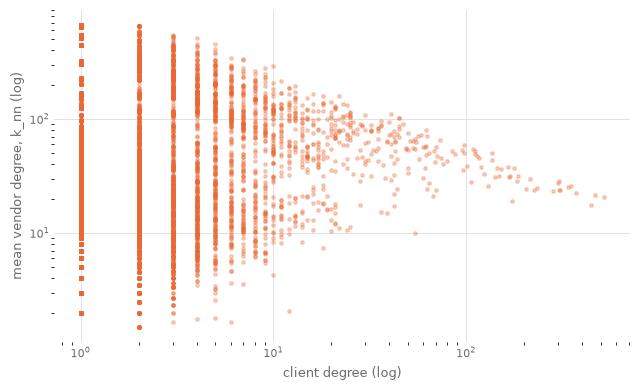

client knn range: 1.50 to 666.00


In [35]:
client_nodes_giant = [n for n in giant if n[0] == "C"]
knn = nx.average_neighbor_degree(giant, nodes=client_nodes_giant)
xs = np.array([client_deg[n] for n in client_nodes_giant])
ys = np.array([knn[n] for n in client_nodes_giant])
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(xs, ys, s=6, alpha=0.3, color=ORANGE)
ax.set_xscale("log"); ax.set_yscale("log")
style(ax, "client degree (log)", "mean vendor degree, k_nn (log)")
fig.tight_layout()
plt.show()
print(f"client knn range: {ys.min():.2f} to {ys.max():.2f}")

The real directed r (printed above) is more negative than the `rewire()` null: the giant component
is somewhat more disassortative than its own degree sequence forces on its own. The gap is small in
absolute terms (roughly a hundredth), but the null's standard deviation over the giant's 41,212 edges is tiny
too, so even that small gap reads as several standard deviations. Most of the disassortativity
comes from the degree sequence itself, the way Marvel's did; the part left over after the
`rewire()` null is small but points the same way, not the opposite way. `k_nn(k)` for clients
(plotted above) is noisy and only weakly related to client degree once plotted point by point,
unlike the clean disassortative slope Marvel showed: the aggregate r is small and negative, but no
single client degree bracket dominates it.

## Cliques

A clique needs every pair in the set linked. In a bipartite graph the largest possible clique is a
single edge: any three nodes must include two from the same side, and same-side nodes are never
linked. So the clique number is exactly 2, and it holds for every bipartite graph, not just this
one; there is nothing to compute. Bicliques (a firm set and a client set where every firm links to
every client) are the bipartite analogue of a dense group, but finding them is its own (expensive)
combinatorial search and the outsourcing market's client-per-firm patterns already appear in
2.8's clustering and 4.5's communities, so we do not chase bicliques separately here.

In [36]:
clique_no = max(len(c) for c in nx.find_cliques(nx.Graph([(1, 2)])))
assert clique_no == 2  # a bipartite graph's ceiling, illustrated
print("clique number of any bipartite graph: 2 (shown on a single edge above; holds for this network too)")

clique number of any bipartite graph: 2 (shown on a single edge above; holds for this network too)


## 4.5: Louvain, as code

Weighted Louvain (`louvain()` in `analysis/week04_staffing.py`, igraph's `community_multilevel`,
about 25 times faster than networkx's) on the weighted giant, five seeds, and the published numbers
(100 seeds, from `analysis/week04_staffing.json`) printed beside ours.

In [37]:
import json
published = json.load(open("../analysis/week04_staffing.json"))["main"]

runs5 = [louvain(giant, SEED + i) for i in range(LOUVAIN_SEEDS)]
for i, (parts, q) in enumerate(runs5):
    print(f"seed {i}: {len(parts)} communities, Q = {q:.4f}")

best_parts, best_q = max(runs5, key=lambda r: r[1])
member = labels(best_parts)
print(f"\nbest of {LOUVAIN_SEEDS} seeds: {len(best_parts)} communities, Q = {best_q:.4f}")
print(f"published, over 100 seeds: median community count "
      f"{published['modularity']['communities_median']}, mean Q "
      f"{published['modularity']['weighted_vs_rewired']['real']} "
      f"(sd {published['modularity']['weighted_vs_rewired']['real_sd']})")

seed 0: 70 communities, Q = 0.5974
seed 1: 66 communities, Q = 0.5958
seed 2: 70 communities, Q = 0.5961
seed 3: 66 communities, Q = 0.5968
seed 4: 74 communities, Q = 0.5955

best of 5 seeds: 70 communities, Q = 0.5974
published, over 100 seeds: median community count 70, mean Q 0.5963 (sd 0.0008)


In [38]:
member_maps = [labels(p) for p, _ in runs5]
nodes_giant = list(giant)
nmi5 = np.zeros((LOUVAIN_SEEDS, LOUVAIN_SEEDS))
for i in range(LOUVAIN_SEEDS):
    for j in range(LOUVAIN_SEEDS):
        a = [member_maps[i][n] for n in nodes_giant]
        b = [member_maps[j][n] for n in nodes_giant]
        nmi5[i, j] = shuffled_nmi(a, b, rng, times=1)[0] if i != j else 1.0
print("5x5 NMI between seeds:")
print(pd.DataFrame(nmi5, index=[f"seed{i}" for i in range(LOUVAIN_SEEDS)],
                    columns=[f"seed{i}" for i in range(LOUVAIN_SEEDS)]).round(3))
off_diag = nmi5[~np.eye(LOUVAIN_SEEDS, dtype=bool)]
print(f"\nlowest pairwise NMI between two runs: {off_diag.min():.3f}   "
      f"(published nmi_between_seeds_median over 100 runs: {published['modularity']['nmi_between_seeds_median']})")

5x5 NMI between seeds:
       seed0  seed1  seed2  seed3  seed4
seed0  1.000  0.695  0.725  0.726  0.731
seed1  0.695  1.000  0.714  0.703  0.715
seed2  0.725  0.714  1.000  0.706  0.733
seed3  0.726  0.703  0.706  1.000  0.770
seed4  0.731  0.715  0.733  0.770  1.000

lowest pairwise NMI between two runs: 0.695   (published nmi_between_seeds_median over 100 runs: 0.731)


In [39]:
# Per-client "does this client keep its own main vendor's community across seeds": the most
# unstable large clients are the ones where the answer flips between runs.
per_client = rows.groupby(["client", "employer"]).size().rename("filings").reset_index()
totals = per_client.groupby("client")["filings"].sum()
vendors_n = per_client.groupby("client")["employer"].nunique()
main_vendor = per_client.sort_values("filings").groupby("client").tail(1).set_index("client")["employer"]
multi = vendors_n[vendors_n >= 2].index
big_clients = totals[totals >= MIN_FILINGS].index

with_vendor_by_seed = []
for m in member_maps:
    with_vendor_by_seed.append({c: m.get(("C", c)) == m.get(("F", main_vendor[c]))
                                 for c in multi if ("C", c) in m and ("F", main_vendor[c]) in m})
common = set.intersection(*[set(d) for d in with_vendor_by_seed])
flips = [c for c in common if len(set(d[c] for d in with_vendor_by_seed)) > 1]
flips_big = [c for c in flips if c in set(big_clients)]
flips_big.sort(key=lambda c: -totals[c])
print(f"clients with 2+ vendors whose 'shares community with own main vendor' answer flips across seeds: "
      f"{len(flips)} of {len(common)}")
print("largest such clients:")
for c in flips_big[:8]:
    print(f"  {resolver().label(c):<30} filings {int(totals[c]):>5}  vendors {int(vendors_n[c])}")

clients with 2+ vendors whose 'shares community with own main vendor' answer flips across seeds: 441 of 4090
largest such clients:
  Wells Fargo                    filings  1547  vendors 468
  Capital One                    filings  1136  vendors 446
  JPMorgan Chase                 filings  1125  vendors 372
  T-Mobile                       filings   919  vendors 339
  Walmart                        filings   871  vendors 302
  Toyota                         filings   563  vendors 178
  Fiserv                         filings   544  vendors 169
  Vanguard                       filings   503  vendors 224


In [40]:
strength_giant = dict(giant.degree(weight="weight"))
print("largest communities (best-of-5 partition), by top firms and clients:")
for part in sorted(best_parts, key=lambda p: -sum(strength_giant[n] for n in p))[:5]:
    fnodes = sorted((n for n in part if n[0] == "F"), key=lambda n: -strength_giant[n])[:4]
    cnodes = sorted((n for n in part if n[0] == "C"), key=lambda n: -strength_giant[n])[:5]
    print(f"\ncommunity: {len(part)} nodes, {sum(strength_giant[n] for n in part):,} total filings")
    print("  top firms:  ", ", ".join(resolver().label(n[1]) for n in fnodes))
    print("  top clients:", ", ".join(resolver().label(n[1]) for n in cnodes))

largest communities (best-of-5 partition), by top firms and clients:

community: 1168 nodes, 25,338 total filings
  top firms:   Tata Consultancy Services, LTIMindtree, CGI Technologies and Solutions, Iris Software
  top clients: Citigroup, PNC, Johnson & Johnson, Cisco, Cigna

community: 1814 nodes, 18,561 total filings
  top firms:   Compunnel Software, Kforce, Mastech Digital Technologies, Photon Infotech
  top clients: Fidelity Investments, Capital One, Walmart, Vanguard, Intuit

community: 1003 nodes, 14,272 total filings
  top firms:   Cognizant, EXL, Cigniti Technologies, Cognier
  top clients: CVS Health, Northern Trust, BNY Mellon, American Airlines, Travelers

community: 1027 nodes, 13,998 total filings
  top firms:   Infosys, Infostretch, ASM America, Inrika
  top clients: Apple, Charter Communications, Toyota, Truist, Goldman Sachs

community: 962 nodes, 11,787 total filings
  top firms:   Wipro, Mphasis, Virtusa, Persistent Systems
  top clients: JPMorgan Chase, Charles Sc

In [41]:
sector_clients = [c for c in multi if ("C", c) in member and names.naics2(c)]
comm_sector = [member[("C", c)] for c in sector_clients]
sector_labels = [names.naics2(c) for c in sector_clients]
ind_obs, ind_p = shuffled_nmi(comm_sector, sector_labels, rng, times=SHUFFLE_NMI)

comm_all = [member[("C", c)] for c in multi if ("C", c) in member]
vendor_labels_all = [main_vendor[c] for c in multi if ("C", c) in member]
ven_obs, ven_p = shuffled_nmi(comm_all, vendor_labels_all, rng, times=SHUFFLE_NMI)

print(f"NMI(community, sector), clients with 2+ vendors and a sector label ({len(sector_clients)}): "
      f"{ind_obs:.3f}  p={ind_p:.4f}   published: {published['industry_or_vendor']['nmi_community_industry']}")
print(f"NMI(community, main vendor), clients with 2+ vendors ({len(comm_all)}): "
      f"{ven_obs:.3f}  p={ven_p:.4f}   published: {published['industry_or_vendor']['nmi_community_main_vendor']}")
print("\nOur best-of-5 partition knows far more about a client's main vendor than its industry: "
      "the vendor label has a head start, since it is defined from the very network Louvain splits.")

NMI(community, sector), clients with 2+ vendors and a sector label (862): 0.171  p=0.0010   published: 0.16
NMI(community, main vendor), clients with 2+ vendors (4090): 0.648  p=0.0010   published: 0.638

Our best-of-5 partition knows far more about a client's main vendor than its industry: the vendor label has a head start, since it is defined from the very network Louvain splits.


In [42]:
t0 = time.time()
gm_core = nx.community.greedy_modularity_communities(core, weight="weight")
gm_q = nx.community.modularity(core, gm_core, weight="weight")
print(f"greedy modularity on core: {len(gm_core)} communities, Q = {gm_q:.4f}   ({time.time() - t0:.1f}s)")

core_louvain_parts, core_louvain_q = louvain(core, SEED)
member_core_louvain = labels(core_louvain_parts)
member_gm = {n: i for i, part in enumerate(gm_core) for n in part}
nmi_gm_louvain = shuffled_nmi([member_core_louvain[n] for n in core], [member_gm[n] for n in core], rng, times=1)[0]
print(f"Louvain on core: {len(core_louvain_parts)} communities, Q = {core_louvain_q:.4f}")
print(f"NMI(greedy modularity, Louvain) on core: {nmi_gm_louvain:.3f}")

greedy modularity on core: 55 communities, Q = 0.5660   (29.6s)
Louvain on core: 50 communities, Q = 0.5673
NMI(greedy modularity, Louvain) on core: 0.736


Greedy modularity merges communities one pair at a time, always taking the single best merge
available at that step, and never revisits an earlier merge once made; Louvain's second phase
collapses each community into a supernode and keeps optimizing from there, so a locally bad-looking
early move can still pay off once the picture changes. On the core the two land close together
(Q printed above): the greedy algorithm's one-shot merges cost it little here, though the method
that can revisit its own decisions still comes out slightly ahead.

## 4.6: Compared to what, and how stable

Q of the real giant against 20 `rewire()` draws (each scored on its own giant component, the
like-for-like null `week04_staffing.main()` uses, since a rewired network splits into hundreds of
pieces and Louvain would otherwise be free to call each piece its own community) and against 20
`gnmk` draws (compared only with the unweighted real Q, since `gnmk` carries no weights). Both
counts match the brief's own 20; the published script runs 100 and we quote it beside ours.

In [43]:
plain_giant = nx.Graph(); plain_giant.add_edges_from(giant.edges())
_, plain_q = louvain(plain_giant, SEED)

null_q_rewire, null_q_gnmk_unweighted = [], []
n_firms_giant = sum(1 for n in giant if n[0] == "F")
n_clients_giant = sum(1 for n in giant if n[0] == "C")
m_giant = giant.number_of_edges()
for i in tracked("4.6: rewire + gnmk modularity nulls", DRAWS_MOD_NULL):
    h = rewire(giant, rng)
    hg = giant_of(h)
    null_q_rewire.append(louvain(hg, SEED + i)[1])
    gnm_g = gnmk_labeled(n_firms_giant, n_clients_giant, m_giant, SEED + i)
    gnm_g_giant = giant_of(gnm_g)
    null_q_gnmk_unweighted.append(louvain(gnm_g_giant, SEED + i)[1])
null_q_rewire = np.array(null_q_rewire)
null_q_gnmk_unweighted = np.array(null_q_gnmk_unweighted)

z_rewire = (best_q - null_q_rewire.mean()) / null_q_rewire.std()
z_gnmk = (plain_q - null_q_gnmk_unweighted.mean()) / null_q_gnmk_unweighted.std()
print(f"real weighted Q = {best_q:.4f}  vs rewire() null mean {null_q_rewire.mean():.4f} "
      f"sd {null_q_rewire.std():.4f}   z = {z_rewire:.1f}")
print(f"  published weighted_vs_rewired: real {published['modularity']['weighted_vs_rewired']['real']}, "
      f"null {published['modularity']['weighted_vs_rewired']['null']}, "
      f"z {published['modularity']['weighted_vs_rewired']['z']}")
print(f"\nreal unweighted Q = {plain_q:.4f}  vs gnmk (unweighted) null mean "
      f"{null_q_gnmk_unweighted.mean():.4f} sd {null_q_gnmk_unweighted.std():.4f}   z = {z_gnmk:.1f}")
print(f"  published wiring_only (rewire, not gnmk): real {published['modularity']['wiring_only']['real']}, "
      f"null {published['modularity']['wiring_only']['null']}, z {published['modularity']['wiring_only']['z']}")

4.6: rewire + gnmk modularity nulls: 2/20 (10%), 5s elapsed, about 45s left


4.6: rewire + gnmk modularity nulls: 4/20 (20%), 8s elapsed, about 34s left


4.6: rewire + gnmk modularity nulls: 6/20 (30%), 13s elapsed, about 30s left


4.6: rewire + gnmk modularity nulls: 8/20 (40%), 18s elapsed, about 27s left


4.6: rewire + gnmk modularity nulls: 10/20 (50%), 23s elapsed, about 23s left


...

4.6: rewire + gnmk modularity nulls: 14/20 (70%), 34s elapsed, about 14s left


4.6: rewire + gnmk modularity nulls: 16/20 (80%), 38s elapsed, about 9s left


4.6: rewire + gnmk modularity nulls: 18/20 (90%), 42s elapsed, about 4s left


4.6: rewire + gnmk modularity nulls: 20/20 (100%), 45s elapsed, about 0s left


real weighted Q = 0.5974  vs rewire() null mean 0.7365 sd 0.0013   z = -106.5
  published weighted_vs_rewired: real 0.5963, null 0.7362, z -89.4

real unweighted Q = 0.5740  vs gnmk (unweighted) null mean 0.5294 sd 0.0011   z = 40.3
  published wiring_only (rewire, not gnmk): real 0.5725, null 0.525, z 50.13


In [44]:
wc = published["modularity"]["weights_check"]
print("published decomposition of Q into its two terms (real weights vs. shuffled weights, same wiring):")
print(f"  inside-community filing share: real {wc['real_inside_share']}   shuffled {wc['shuffled_inside_share']}")
print(f"  penalty term:                  real {wc['real_penalty']}   shuffled {wc['shuffled_penalty']}")
print(f"  filings to multi-vendor clients: {wc['filings_to_multi_vendor_clients_share']:.1%} of all filings")
print(f"  crossing filings on multi-vendor links: {wc['crossing_filings_on_multi_vendor_links_share']:.1%}")

published decomposition of Q into its two terms (real weights vs. shuffled weights, same wiring):
  inside-community filing share: real 0.6477   shuffled 0.767
  penalty term:                  real 0.0514   shuffled 0.0149
  filings to multi-vendor clients: 81.5% of all filings
  crossing filings on multi-vendor links: 100.0%


The weighted real Q sits below its `rewire()` null (a negative z, matching the published sign).
The published decomposition (printed above) says why: shuffling the filing counts raises the
inside-community share (0.767 against the real 0.648) and lowers the penalty term (0.015 against
the real 0.051), and Q is the first minus the second, so both changes push Q up. 81.5% of filings
go to clients with two or more vendors, and every filing that crosses a community boundary sits on
one of those multi-vendor links (100%, printed above): a single-vendor client's filings always sit
inside its one firm's community, so when weights are dealt out at random, more of that heavy
single-vendor weight lands on links that already sit inside a community by construction, and less
weight concentrates on the large multi-vendor clients whose links are the ones that cross. That
raises the inside share and flattens community strengths, which lowers the penalty. The unweighted
comparison goes the other way (a positive z): the wiring alone, ignoring filing counts, is more
modular than a rewired equivalent, so the community structure does not depend on the weights alone.

## 4.9: Infomap vs Louvain

Infomap via igraph's `community_infomap` (`infomap()` in `week04_staffing.py`; the pip package
`infomap` is not installed, per the environment note).

In [45]:
t0 = time.time()
modules, codelength = infomap(giant, SEED)
member_info = labels(modules)
print(f"Infomap in {time.time() - t0:.1f}s: {len(modules)} modules, codelength {codelength:.2f} bits")
print(f"published modules (their single seed): {published['infomap']['modules']}")

Infomap in 1.3s: 1713 modules, codelength 7.75 bits
published modules (their single seed): 1713


In [46]:
nmi_info_louvain = shuffled_nmi([member[n] for n in nodes_giant], [member_info[n] for n in nodes_giant],
                                 rng, times=1)[0]
print(f"NMI(Infomap, Louvain) our best-of-5: {nmi_info_louvain:.3f}   "
      f"published nmi_with_louvain (their best-of-100): {published['infomap']['nmi_with_louvain']}")

sizes = np.array(sorted((len(m) for m in modules), reverse=True))
print(f"Infomap: {len(modules)} modules, median size {np.median(sizes):.0f}, "
      f"{(sizes <= 5).sum()} modules of 5 nodes or fewer ({(sizes <= 5).mean():.1%})")
print(f"largest module: {sizes[0]} nodes ({sizes[0] / giant.number_of_nodes():.1%} of the giant)   "
      f"published: {published['infomap']['largest_module_share_of_nodes']:.1%}")

NMI(Infomap, Louvain) our best-of-5: 0.657   published nmi_with_louvain (their best-of-100): 0.651
Infomap: 1713 modules, median size 7, 678 modules of 5 nodes or fewer (39.6%)
largest module: 463 nodes (2.1% of the giant)   published: 2.1%


In [47]:
# How does Louvain's largest communities split under Infomap?
top_louvain = sorted(best_parts, key=lambda p: -len(p))[:10]
print("the ten largest Louvain communities, and how many Infomap modules their members fall into:")
for i, part in enumerate(top_louvain):
    info_ids = {member_info[n] for n in part if n in member_info}
    print(f"  community {i}: {len(part):>5} nodes  ->  {len(info_ids):>3} Infomap modules")

the ten largest Louvain communities, and how many Infomap modules their members fall into:
  community 0:  1814 nodes  ->  239 Infomap modules
  community 1:  1275 nodes  ->  145 Infomap modules
  community 2:  1168 nodes  ->  134 Infomap modules
  community 3:  1027 nodes  ->  130 Infomap modules
  community 4:  1003 nodes  ->  118 Infomap modules
  community 5:   962 nodes  ->  129 Infomap modules
  community 6:   866 nodes  ->   89 Infomap modules
  community 7:   714 nodes  ->  103 Infomap modules
  community 8:   713 nodes  ->  116 Infomap modules
  community 9:   697 nodes  ->   97 Infomap modules


Infomap and Louvain agree only moderately (NMI printed above). Infomap's 1,713 modules have a
median size of 7 and 40% hold 5 nodes or fewer (printed above), against Louvain's much larger,
much fewer communities on the same giant: Infomap's map-equation objective is satisfied by leaving
many small, thinly connected corners as their own small module, where Louvain's modularity
objective merges them into a larger community instead. The table above shows this concretely: each
of Louvain's ten largest communities (697 to 1,814 nodes) splits across 89 to 239 Infomap modules,
so the two methods disagree inside the large, well-connected part of the network, not only at its
edges.

## 4.11: The backbone, and the figure

Strength vs. degree, the hand-written disparity filter validated against `analysis/week04_where.
disparity()`, the alpha/threshold table, and the backbone drawing.

firms: farthest from the diagonal (strength/degree) is Gradestaffing, degree 1, strength 55 (55.0x)
clients: farthest from the diagonal (strength/degree) is Renewal Rehab, degree 2, strength 762 (381.0x)


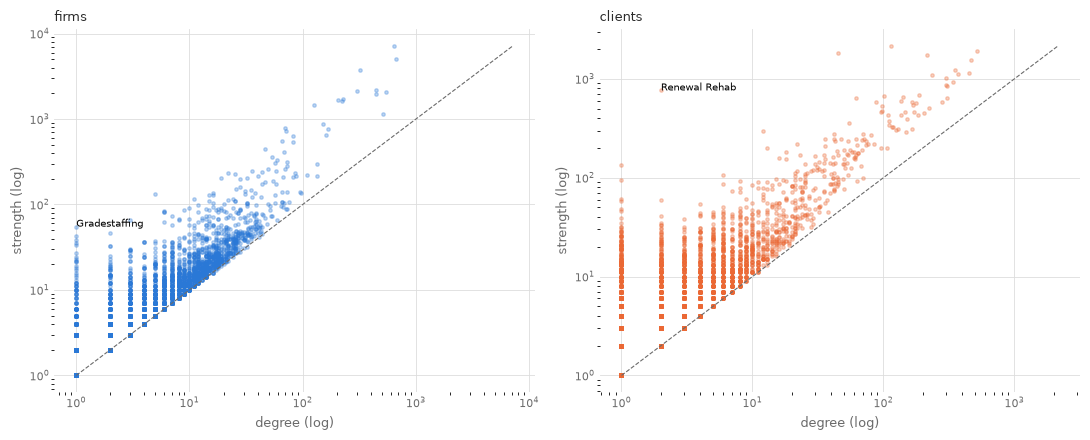

In [48]:
strength_all = dict(giant.degree(weight="weight"))
degree_all = dict(giant.degree())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, side, color, label in [(axes[0], "F", BLUE, "firms"), (axes[1], "C", ORANGE, "clients")]:
    ns = [n for n in giant if n[0] == side]
    xs = np.array([degree_all[n] for n in ns])
    ys = np.array([strength_all[n] for n in ns])
    ax.scatter(xs, ys, s=6, alpha=0.3, color=color)
    lim = [1, max(xs.max(), ys.max())]
    ax.plot(lim, lim, color=MUTED, linewidth=0.8, linestyle="--")
    ax.set_xscale("log"); ax.set_yscale("log")
    style(ax, "degree (log)", "strength (log)")
    ax.set_title(label, fontsize=9, loc="left", color=INK)
    ratio = ys / xs
    far = ns[np.argmax(ratio)]
    ax.annotate(resolver().label(far[1])[:22], (xs[np.argmax(ratio)], ys[np.argmax(ratio)]), fontsize=7)
    print(f"{label}: farthest from the diagonal (strength/degree) is {resolver().label(far[1])}, "
          f"degree {degree_all[far]}, strength {strength_all[far]} ({strength_all[far] / degree_all[far]:.1f}x)")
fig.tight_layout()
plt.show()

In [49]:
def disparity_hand(bg):
    '''p-value of every edge under the disparity filter: the smaller of the two endpoints'
    (1 - w/s)^(k-1). An endpoint with one link cannot judge it (both degree 1 -> p = 0).'''
    strength = dict(bg.degree(weight="weight"))
    degree = dict(bg.degree())
    p = {}
    for u, v, w in bg.edges(data="weight"):
        tests = [(1 - w / strength[n]) ** (degree[n] - 1) for n in (u, v) if degree[n] > 1]
        p[(u, v)] = min(tests) if tests else 0.0
    return p


p_hand = disparity_hand(giant)
p_ref = disparity_reference(giant)
diffs = [abs(p_hand[e] - p_ref.get(e, p_ref.get((e[1], e[0])))) for e in p_hand]
print(f"max abs difference, hand vs analysis/week04_where.disparity(): {max(diffs):.2e}")
assert max(diffs) < 1e-12

max abs difference, hand vs analysis/week04_where.disparity(): 0.00e+00


In [50]:
def backbone(bg, p, alpha):
    return [(u, v) for u, v in bg.edges() if p[(u, v)] < alpha]


def single_vendor_share(kept):
    single = sum(1 for u, v in kept if degree_all[u if u[0] == "C" else v] == 1)
    return single, single / len(kept) if kept else 0.0


rows_table = []
for alpha in (0.05, 0.1, 0.2, 0.3, 0.5):
    kept = backbone(giant, p_hand, alpha)
    h = nx.Graph(kept)
    giant_h = max(nx.connected_components(h), key=len) if h.number_of_nodes() else []
    sv, sv_share = single_vendor_share(kept)
    rows_table.append({"alpha": alpha, "links_kept": len(kept), "nodes_with_a_link": h.number_of_nodes(),
                        "giant_component": len(giant_h), "single_vendor_links_kept": sv,
                        "single_vendor_share_of_kept": round(sv_share, 3)})
for wmin in (2, 3, 5):
    kept = [(u, v) for u, v, w in giant.edges(data="weight") if w >= wmin]
    h = nx.Graph(kept)
    giant_h = max(nx.connected_components(h), key=len) if h.number_of_nodes() else []
    sv, sv_share = single_vendor_share(kept)
    rows_table.append({"alpha": f"w>={wmin}", "links_kept": len(kept), "nodes_with_a_link": h.number_of_nodes(),
                        "giant_component": len(giant_h), "single_vendor_links_kept": sv,
                        "single_vendor_share_of_kept": round(sv_share, 3)})
table = pd.DataFrame(rows_table)
print(table.to_string(index=False))
print(f"\nfor reference, single-vendor clients are {single_vendor_clients / n_clients:.1%} of all clients")

alpha  links_kept  nodes_with_a_link  giant_component  single_vendor_links_kept  single_vendor_share_of_kept
 0.05        1738               1559             1000                       126                        0.072
  0.1        2674               2424             1521                       245                        0.092
  0.2        5223               4578             2955                       613                        0.117
  0.3        8658               6644             4780                      1240                        0.143
  0.5       26040              14047            13131                      5529                        0.212
 w>=2       12915               9211             7068                      2860                        0.221
 w>=3        6376               4958             3451                      1249                        0.196
 w>=5        3090               2419             1691                       466                        0.151

for reference, sin

Single-vendor clients are 77.6% of all clients (printed above) but only 7 to 21% of the links the
filter keeps at any of the tested alphas, rising slowly as alpha loosens. A single-vendor client's
one link is judged only from the firm's side (its own degree is 1, so it contributes no test to the
minimum), so the link survives only when that filing is a significant share of the *firm's*
strength, which is rare once a firm has hundreds of clients (1.6). The filter is not neutral to
single-vendor clients: it drops most of them at every alpha tested, and progressively fewer of them
as alpha rises.

In [51]:
# Backbone drawing: alpha = 0.2, restricted to the giant component among the top ~40 firms by
# strength and their clients (a full 10k-node drawing is a hairball).
ALPHA_DRAW = 0.2
top_firms_draw = sorted([n for n in giant if n[0] == "F"], key=lambda n: -strength_all[n])[:40]
nbrs = set(c for f in top_firms_draw for c in giant.neighbors(f))
sub_nodes = set(top_firms_draw) | nbrs
sub = induced(giant, sub_nodes)
p_sub = disparity_hand(sub)
kept_sub = backbone(sub, p_sub, ALPHA_DRAW)
back = nx.Graph(kept_sub)
back_giant = back.subgraph(max(nx.connected_components(back), key=len)).copy()
print(f"subnetwork (top 40 firms + clients): {sub.number_of_nodes()} nodes, {sub.number_of_edges()} edges")
print(f"backbone at alpha={ALPHA_DRAW}: {back.number_of_edges()} links kept of {sub.number_of_edges()} "
      f"({back.number_of_edges() / sub.number_of_edges():.1%}), "
      f"drawing its giant component: {back_giant.number_of_nodes()} nodes")

subnetwork (top 40 firms + clients): 4426 nodes, 6823 edges
backbone at alpha=0.2: 1110 links kept of 6823 (16.3%), drawing its giant component: 695 nodes


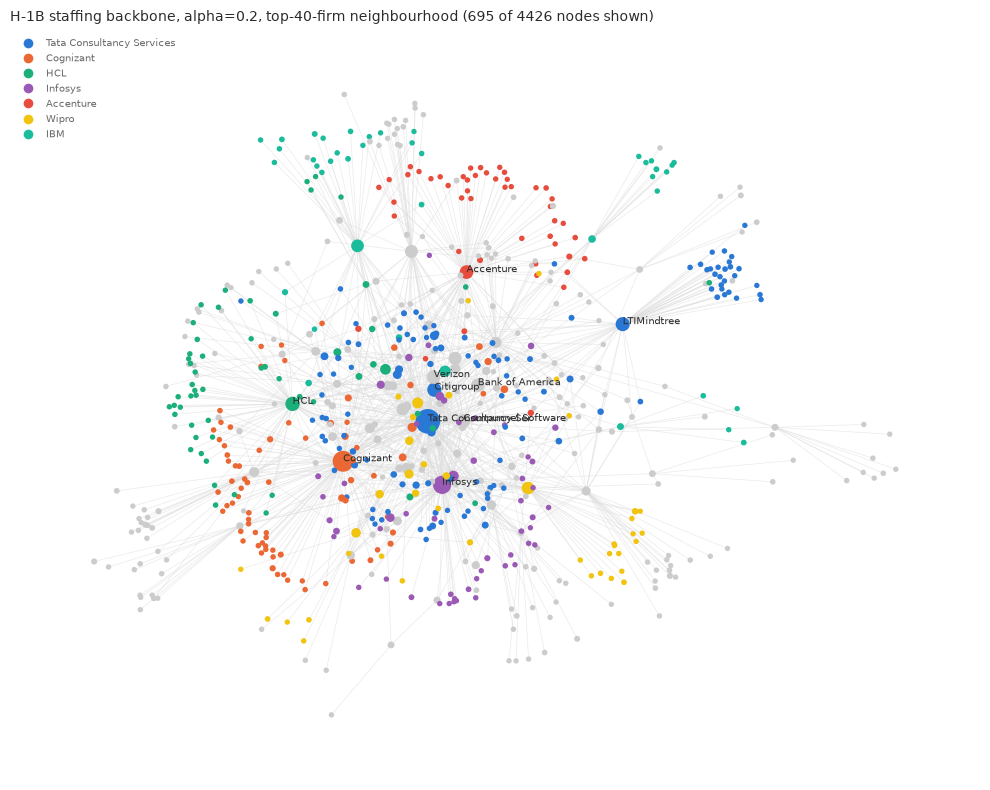

In [52]:
# Colour by Louvain community computed on the FULL weighted network (member, from 4.5), not on the
# backbone itself, per the brief's advice against clustering a visualization-only object.
comm_ids = sorted({member.get(n, -1) for n in back_giant}, key=lambda c: -sum(
    1 for n in back_giant if member.get(n, -1) == c))
top_comms = comm_ids[:7]
palette = [BLUE, ORANGE, GREEN, "#9b59b6", "#e74c3c", "#f1c40f", "#1abc9c"]
comm_color = {c: palette[i] for i, c in enumerate(top_comms)}

def label_of_comm(c):
    members = [n for n in back_giant if member.get(n, -1) == c and n[0] == "F"]
    if not members:
        return f"community {c}"
    top = max(members, key=lambda n: strength_all[n])
    return resolver().label(top[1])

pos = nx.spring_layout(back_giant, seed=SEED, weight="weight", k=0.6)
node_strength = np.array([strength_all[n] for n in back_giant])
sizes = 15 + 300 * (node_strength - node_strength.min()) / (node_strength.max() - node_strength.min() + 1)
colors = [comm_color.get(member.get(n, -1), "#CCCCCC") for n in back_giant]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(back_giant, pos, ax=ax, edge_color=GRID, width=0.5, alpha=0.6)
nx.draw_networkx_nodes(back_giant, pos, ax=ax, node_size=sizes, node_color=colors, linewidths=0)

top10 = sorted(back_giant.nodes(), key=lambda n: -strength_all[n])[:10]
for n in top10:
    ax.annotate(resolver().label(n[1])[:20], pos[n], fontsize=7, color=INK)

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=comm_color[c], markersize=8,
                       label=label_of_comm(c)) for c in top_comms]
ax.legend(handles=handles, frameon=False, fontsize=7, loc="upper left", labelcolor=MUTED)
ax.set_axis_off()
ax.set_title(f"H-1B staffing backbone, alpha={ALPHA_DRAW}, top-40-firm neighbourhood "
             f"({back_giant.number_of_nodes()} of {sub.number_of_nodes()} nodes shown)",
             fontsize=10, color=INK, loc="left")
fig.tight_layout()
plt.show()

**Caption.** Disparity filter, alpha = 0.2, applied within the neighbourhood of the 40 largest
firms by strength (4,426 candidate nodes, 6,823 candidate links); 1,110 links kept (16.3%), drawing
the giant component of what remains (695 nodes). Node colour is the firm's or client's Louvain
community from the full weighted network (4.5), not from the backbone itself, per the brief's
advice against clustering a visualization-only object; node size is strength; the ten
highest-strength nodes are labelled.

alpha=0.1: 697 of 6823 links kept (10.2%), giant component 429 nodes


alpha=0.3: 1522 of 6823 links kept (22.3%), giant component 950 nodes


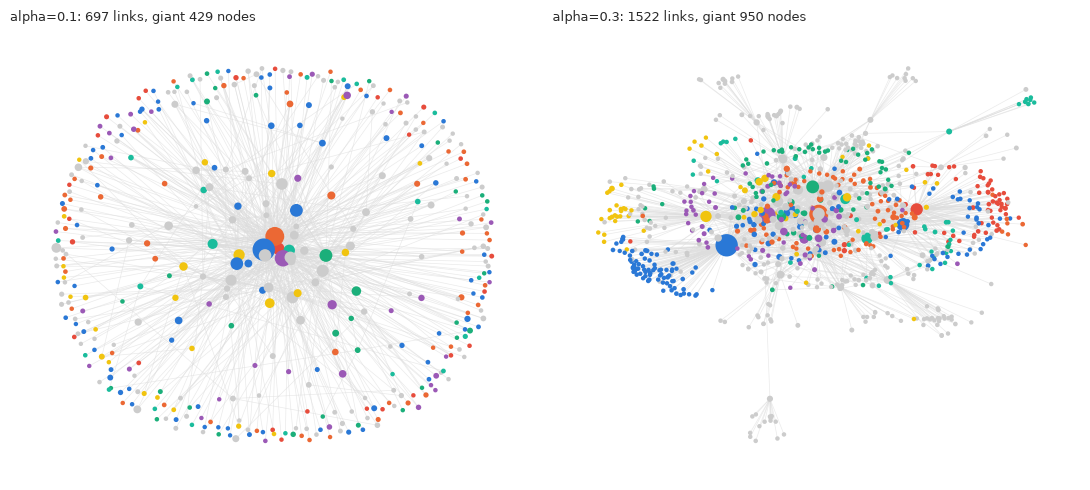

In [53]:
# Two more alphas, side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, a in zip(axes, (0.1, 0.3)):
    kept_a = backbone(sub, p_sub, a)
    ba = nx.Graph(kept_a)
    if ba.number_of_edges() == 0:
        ax.set_title(f"alpha={a}: no links survive", fontsize=9)
        ax.set_axis_off()
        continue
    ba_giant = ba.subgraph(max(nx.connected_components(ba), key=len)).copy()
    pos_a = nx.spring_layout(ba_giant, seed=SEED, weight="weight", k=0.6)
    colors_a = [comm_color.get(member.get(n, -1), "#CCCCCC") for n in ba_giant]
    strengths_a = np.array([strength_all[n] for n in ba_giant])
    sizes_a = 10 + 250 * (strengths_a - strengths_a.min()) / (strengths_a.max() - strengths_a.min() + 1)
    nx.draw_networkx_edges(ba_giant, pos_a, ax=ax, edge_color=GRID, width=0.5, alpha=0.6)
    nx.draw_networkx_nodes(ba_giant, pos_a, ax=ax, node_size=sizes_a, node_color=colors_a, linewidths=0)
    ax.set_title(f"alpha={a}: {ba.number_of_edges()} links, giant {ba_giant.number_of_nodes()} nodes",
                 fontsize=9, color=INK, loc="left")
    ax.set_axis_off()
    print(f"alpha={a}: {ba.number_of_edges()} of {sub.number_of_edges()} links kept "
          f"({ba.number_of_edges() / sub.number_of_edges():.1%}), giant component {ba_giant.number_of_nodes()} nodes")
fig.tight_layout()
plt.show()

Alpha = 0.1 keeps only 697 of the sub-network's 6,823 links (10.2%), a giant component of 429
nodes: enough to see the two or three biggest outsourcers and their most exclusive clients, but
most mid-sized clients drop out entirely. Alpha = 0.3 keeps 1,522 links (22.3%, giant 950 nodes):
still a real reduction from the raw 6,823, but visibly denser than 0.2's 1,110 links, so the
picture is closer to a hairball again and community boundaries blur. Alpha = 0.2 (1,110 links,
16.3%, giant 695 nodes, printed earlier) is the one we would publish: it removes
enough that the remaining links are individually defensible while keeping enough of the
mid-strength clients that the community structure from 4.5 is still visible in the drawing.

## What we found

- **The bipartite trap bit everywhere.** Clustering, transitivity, triangles and reciprocity are
  all 0 (2.8, cliques, 3.3); every strongly connected component is a single node (3.3); 69.1% of
  nodes (every client) are dangling in the firm-&rarr;client PageRank walk (3.7). Each exercise
  needed a bipartite-appropriate substitute, printed beside the degenerate value.
- **14,679 of 18,924 clients (1.6) use one vendor**, but their links make up only 7 to 21% of what
  the disparity filter keeps at any tested alpha (4.11): a single-vendor link survives only when
  that filing is a significant share of the firm's strength too, which is rare for a large firm.
- **The friendship paradox holds on both sides of the bipartite split** (2.9): a client's random
  vendor, and a firm's random client, both average well above their own side's mean degree, and
  the effect survives `rewire()` (same variance, scrambled wiring) but mostly disappears under
  `gnmk` (near-Poisson degrees, low variance).
- **Bipartite clustering (Robins-Alexander) sits many standard deviations above both nulls** (2.8):
  clients that share one vendor tend to share others too.
- **The giant component is slightly more disassortative than its degree sequence forces** (3.9):
  directed r = -0.135 against a `rewire()` null of -0.123 (z = -10), a small gap magnified by the
  null's tiny standard deviation over the giant's 41,212 edges. Most of the disassortativity is explained by
  the degree sequence alone, the way Marvel's was.
- **Louvain communities track a client's main vendor far more than its industry sector** (4.5),
  matching the published result; Infomap agrees with Louvain only moderately (4.9).
- **Weighted modularity is lower than its `rewire()` null while unweighted modularity is higher**
  (4.6), the same sign pattern as the published numbers. The published decomposition shows why:
  shuffling filing counts raises the inside-community share and lowers the penalty term, because
  a single-vendor client's weight always sits inside its one firm's community, so random weights
  land less on the multi-vendor links that cross community boundaries.